# Gavin Workspace: Voter Turnout Modeling

> Goal: predict 2024 general election turnout (`VoteFlag`) using progressively richer sets of voter attributes.

## Notebook Roadmap
1. Setup and helper functions
2. Column reference dictionary
3. Data load and base cleaning
4. Baseline Naive Bayes model (core demographics)
5. Expanded Naive Bayes model (full engineered feature set)
6. Model interpretation (feature importance + SHAP)

> Notes
- Cells are organized so each major stage starts with a markdown header.
- Baseline and expanded pipelines are intentionally separated for easier comparison.

In [42]:
# Importing basic packages
import numpy as np 
import pandas as pd 

# Data visualization
import matplotlib.pyplot as plt 
import seaborn as sns

# ML
# 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.impute import SimpleImputer
import shap
#Addressing class imbalance
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# File systems
import os
import string

In [43]:
# Functions
def scatter_matrix_ex(numeric_df, custom_alpha=0.05):
  axs = pd.plotting.scatter_matrix(numeric_df, figsize=(30,16), alpha=custom_alpha, diagonal='kde')

  numeric_n = len(numeric_df.columns)
  for x in range(numeric_n):
      for y in range(numeric_n):
          ax = axs[x, y]
          ax.xaxis.label.set_rotation(90)
          ax.yaxis.label.set_rotation(0)
          ax.yaxis.labelpad = 50
          ax.xaxis.label.set_fontsize(10)
          ax.yaxis.label.set_fontsize(10)
  plt.show()

def corr_matrix_ex(numeric_df, df_name = 'Given Dataframe'):
  data_corrmat = numeric_df.corr()
  plt.figure(figsize=(30, 16))
  plt.title(f"Correlation Matrix for {df_name}")
  sns.heatmap(data_corrmat,
              cmap='coolwarm',
              fmt='.2f',
              annot=True,
              vmin = -1,
              vmax = 1,
              annot_kws={"size": 10})
  plt.tight_layout()
  plt.show()

def givendf_investigation(given_df):
  given_numerics = given_df.select_dtypes(include=[np.number]).columns.tolist()
  given_categoricals = given_df.select_dtypes(include=['object','category']).columns.tolist()

  if len(given_categoricals) % 2 == 0:
    given_rows = len(given_categoricals) // 2
  else:
    given_rows = (len(given_categoricals) // 2) + 1

  fig, axes = plt.subplots(given_rows, 2, figsize=(14, given_rows * 4))
  for i_cat, cat_num in zip( given_categoricals, range(len(given_categoricals)) ):
    row_idx = cat_num // 2
    col_idx = cat_num % 2
    sns.countplot(data = given_df, x=i_cat, ax=axes[row_idx, col_idx], stat="percent")
    axes[row_idx, col_idx].set_xlabel('')
    axes[row_idx, col_idx].set_ylabel(f"% by {i_cat}") # Set y-label to the actual column name
  plt.tight_layout()
  plt.show()

  if len(given_numerics) % 3 == 0:
    given_rows = len(given_numerics) // 3
  elif len(given_numerics) < 3:
    given_rows = 1
  else:
    given_rows = (len(given_numerics) // 3) + 1


  if given_rows == 1:
    fig, axes = plt.subplots(1, 3, figsize=(14, given_rows * 4))
    for i_cat, cat_num in zip(given_numerics, range(len(given_numerics)) ):
      row_idx = cat_num // 3
      col_idx = cat_num % 3
      sns.histplot(data = given_df, x=i_cat, alpha=0.5, ax=axes[col_idx], element="step")
      axes[col_idx].axvline(np.mean(data[i_cat]), color='red', linestyle='--', label='Population Mean', linewidth=0.8, alpha = 0.6)
      axes[col_idx].axvline(np.median(data[i_cat]), color='black', linestyle='--', label='Population Median', linewidth=0.8, alpha = 0.6)
      axes[col_idx].set_xlabel('')
      axes[col_idx].set_ylabel(f"Count of Value of {i_cat}") # Set y-label to the actual column name

      if col_idx % 3 == 1:
        axes[col_idx].legend()

  else:
    fig, axes = plt.subplots(given_rows, 3, figsize=(14, given_rows * 4))
    for i_cat, cat_num in zip(given_numerics, range(len(given_numerics)) ):
      row_idx = cat_num // 3
      col_idx = cat_num % 3
      sns.histplot(data = given_df, x=i_cat, alpha=0.5, ax=axes[row_idx, col_idx], element="step")
      axes[row_idx, col_idx].axvline(np.mean(data[i_cat]), color='red', linestyle='--', label='Population Mean', linewidth=0.8, alpha = 0.6)
      axes[row_idx, col_idx].axvline(np.median(data[i_cat]), color='black', linestyle='--', label='Population Median', linewidth=0.8, alpha = 0.6)
      axes[row_idx, col_idx].set_xlabel('')
      axes[row_idx, col_idx].set_ylabel(f"Count of Value of {i_cat}") # Set y-label to the actual column name

      if col_idx % 3 == 1:
        axes[row_idx, col_idx].legend()


  plt.tight_layout()
  plt.show()

def confusion_matrix_ex(y_test, y_pred, y_labels=['Positive','Negative'], y_topic = 'Topic'):
  y_matrix = confusion_matrix(y_test, y_pred)
  y_accuracy = accuracy_score(y_test, y_pred)
  cm = ConfusionMatrixDisplay(confusion_matrix = y_matrix, display_labels=y_labels)
  cm.plot(cmap='Blues')
  plt.suptitle(f'{y_topic} Confusion Matrix', weight=800)
  plt.title(f'Accuracy: {y_accuracy:.3f}')
  plt.show()

def roc_curve_display_ex(esti_provided, X_provided, y_provided, y_topic = 'Topic'):
  rcd = RocCurveDisplay.from_estimator(esti_provided,
                                       X_provided,
                                       y_provided,
                                         plot_chance_level = True)
  plt.fill_between(rcd.fpr, rcd.tpr, rcd.fpr, where=rcd.tpr>rcd.fpr, interpolate=True,  alpha=0.4)
  plt.suptitle(f'{y_topic} ROC-AUC Curve', weight=800)
  plt.title(f'ROC-AUC: {rcd.roc_auc:.3f}')
  plt.show()

## Column Dictionary

> This section defines `CES2024_COLUMNS`, a long-form reference from raw variable names to readable descriptions.

Use this as a lookup when selecting features and documenting transformations later in the notebook.

In [44]:
# Index of all columns within the original dataset, pre-trimming

CES2024_COLUMNS = {
    # â”€â”€ Identifiers & Weights â”€â”€
    "caseid": "Case ID",
    "tookpost": "Took post-election survey",
    "commonweight": "Common content weight (all respondents, adults)",
    "commonpostweight": "Common content post-election weight (both waves, adults)",
    "vvweight": "Vote validation weight (matched to registration, registered adults)",
    "vvweight_post": "Vote validation post weight (both waves & matched, registered adults)",

    # â”€â”€ Consent & Address â”€â”€
    "CCEStake": "Consent to participate",
    "add_confirm": "Confirm address",
    "inputzip": "Input zip code",

    # â”€â”€ Demographics â”€â”€
    "birthyr": "Birth Year",                    # Age = 2024 - birthyr
    "gender4": "Gender",
    "gender4_t": "Gender (text)",
    "educ": "Education",                        # (Include in naive model)
    "race": "Race",
    "race_other": "Race - Other (text)",        # DROP
    "hispanic": "Hispanic",

    # â”€â”€ Multiracial (check all) â”€â”€
    "multrace_1": "Multiracial - White",
    "multrace_2": "Multiracial - Black",
    "multrace_3": "Multiracial - Hispanic",
    "multrace_4": "Multiracial - Asian",
    "multrace_5": "Multiracial - Native American",
    "multrace_8": "Multiracial - Middle Eastern",
    "multrace_97": "Multiracial - Other",
    "multrace_98": "Multiracial - Don't know",

    # â”€â”€ Device & Registration â”€â”€
    "comptype": "Device type",
    "votereg": "Voter Registration Status",
    "votereg_f": "Registered to vote (zip confirmation)",
    "regzip": "Registered zip code",

    # â”€â”€ Party ID â”€â”€
    "pid3": "3 point party ID",
    "pid3_t": "3 point party ID (text)",
    "pid7": "7 point Party ID",

    # â”€â”€ Geography â”€â”€
    "inputstate": "State of Residence",
    "region": "Region",
    "ccesmodule": "Team module assigned",

    # â”€â”€ Media use past 24 hrs (check all) â”€â”€
    "CC24_300_1": "Media use past 24 hrs - Used social media",
    "CC24_300_2": "Media use past 24 hrs - Watched TV news",
    "CC24_300_3": "Media use past 24 hrs - Read a newspaper",
    "CC24_300_4": "Media use past 24 hrs - Listened to radio news",
    "CC24_300_5": "Media use past 24 hrs - None of these",

    # â”€â”€ Media use follow-ups â”€â”€
    "CC24_300a": "Media use - TV news type",
    "CC24_300c": "Media use - Newspaper type",

    # â”€â”€ Media use networks (check all) â”€â”€
    "CC24_300b_1": "Media networks - ABC",
    "CC24_300b_2": "Media networks - CBS",
    "CC24_300b_3": "Media networks - NBC",
    "CC24_300b_4": "Media networks - CNN",
    "CC24_300b_5": "Media networks - Fox News",
    "CC24_300b_6": "Media networks - MSNBC",
    "CC24_300b_7": "Media networks - PBS",
    "CC24_300b_8": "Media networks - Other",

    # â”€â”€ Recent social media use (check all) â”€â”€
    "CC24_300d_1": "Recent social media use - Posted a story, photo, video or link about politics",
    "CC24_300d_2": "Recent social media use - Posted a comment about politics",
    "CC24_300d_3": "Recent social media use - Read a story or watched a video about politics",
    "CC24_300d_4": "Recent social media use - Followed a political event",
    "CC24_300d_5": "Recent social media use - Forwarded a story, photo, video or link about politics to friends",
    "CC24_300d_6": "Recent social media use - None of the above",

    # â”€â”€ Economic perceptions â”€â”€
    "CC24_301": "National Economics",
    "CC24_302": "Household income change",
    "CC24_303": "Price change in past year",

    # â”€â”€ Life Changes (check all) â”€â”€
    "CC24_305_1": "Life Changes - Married",
    "CC24_305_2": "Life Changes - Lost a job",
    "CC24_305_3": "Life Changes - Finished school",
    "CC24_305_4": "Life Changes - Retired",
    "CC24_305_5": "Life Changes - Divorced",
    "CC24_305_6": "Life Changes - Had a child",
    "CC24_305_7": "Life Changes - Taken a new job",
    "CC24_305_9": "Life Changes - Been a victim of a crime",
    "CC24_305_10": "Life Changes - Visited an emergency room",
    "CC24_305_11": "Life Changes - Visited a doctor for a regular examination",
    "CC24_305_12": "Life Changes - Received a raise at work",
    "CC24_305_13": "Life Changes - Had a pay cut at work",
    "CC24_305_14": "Life Changes - None of the above",

    # â”€â”€ Health â”€â”€
    "CC24_309e": "General health",

    # â”€â”€ Ukraine (check all) â”€â”€
    "CC24_308a_1": "Ukraine - Do not get involved",
    "CC24_308a_2": "Ukraine - Send food, medicine, and other humanitarian aid to Ukraine",
    "CC24_308a_3": "Ukraine - Impose economic sanctions on Russia",
    "CC24_308a_4": "Ukraine - Provide arms to Ukraine",
    "CC24_308a_5": "Ukraine - Send military support staff to Ukraine (non-combat)",
    "CC24_308a_6": "Ukraine - Send significant force to fight Russia",
    "CC24_308a_7": "Ukraine - Negotiate a peace accord between Russia and Ukraine",
    "CC24_308a_8": "Ukraine - Send aid to affected communities after the conflict to help rebuild",

    # â”€â”€ Israel/Gaza (check all) â”€â”€
    "CC24_308b_1": "Israel/Gaza - Do not get involved",
    "CC24_308b_2": "Israel/Gaza - Send food, medicine and other aid to the communities affected",
    "CC24_308b_3": "Israel/Gaza - Provide arms to Israel",
    "CC24_308b_4": "Israel/Gaza - Provide arms to Hamas",
    "CC24_308b_5": "Israel/Gaza - Send the US Navy and troops to the region",
    "CC24_308b_6": "Israel/Gaza - Send military support staff (non-combat) to Israel",
    "CC24_308b_7": "Israel/Gaza - Send military support staff (non-combat) to Gaza",
    "CC24_308b_8": "Israel/Gaza - Negotiate a peace settlement",
    "CC24_308b_9": "Israel/Gaza - Send aid to affected communities after the conflict",

    # â”€â”€ Emergency expense (check all) â”€â”€
    "CC24_309d_1": "Emergency expense - Put it on credit card, pay off in full",
    "CC24_309d_2": "Emergency expense - Put it on credit card, pay off over time",
    "CC24_309d_3": "Emergency expense - With checking/savings or cash",
    "CC24_309d_4": "Emergency expense - Bank loan or line of credit",
    "CC24_309d_5": "Emergency expense - Borrowing from friend or family",
    "CC24_309d_6": "Emergency expense - Payday loan, deposit advance, or overdraft",
    "CC24_309d_7": "Emergency expense - By selling something",
    "CC24_309d_8": "Emergency expense - Wouldn't be able to pay right now",
    "CC24_309d_9": "Emergency expense - Other",
    "CC24_309d_t": "Emergency expense - Other (text)",

    # â”€â”€ Know Party in Government (grid) â”€â”€
    "CC24_310a": "Know Party in Government - U.S. House of Representatives",
    "CC24_310b": "Know Party in Government - U.S. Senate",
    "CC24_310c": "Know Party in Government - State Senate",
    "CC24_310d": "Know Party in Government - State Lower Chamber",

    # â”€â”€ Know Party of Representative (grid) â”€â”€
    "CC24_311a": "Know Party of Representative - Governor",
    "CC24_311b": "Know Party of Representative - Senator 1",
    "CC24_311c": "Know Party of Representative - Senator 2",
    "CC24_311d": "Know Party of Representative - U.S. House member",

    # â”€â”€ Job Approval Institutions (grid) â”€â”€
    "CC24_312a": "Job Approval - President Biden",
    "CC24_312i": "Job Approval - Vice President Harris",
    "CC24_312b": "Job Approval - U.S. Congress",
    "CC24_312c": "Job Approval - U.S. Supreme Court",
    "CC24_312d": "Job Approval - Governor",
    "CC24_312e": "Job Approval - State Legislature",
    "CC24_312f": "Job Approval - U.S. House member",
    "CC24_312g": "Job Approval - Senator 1",
    "CC24_312h": "Job Approval - Senator 2",

    # â”€â”€ Citizenship & Immigration â”€â”€
    "cit1": "US citizen",
    "immstat": "Immigration background",

    # â”€â”€ Gun control (grid) â”€â”€
    "CC24_321a": "Gun control - Ban assault rifles",
    "CC24_321b": "Gun control - Make it easier to obtain concealed-carry permit",
    "CC24_321c": "Gun control - Require background checks on all gun sales",
    "CC24_321d": "Gun control - Increase police on the street by 10 percent",
    "CC24_321e": "Gun control - Decrease police on the street by 10 percent",
    "CC24_321f": "Gun control - Increase spending on mental health and school safety; confiscate guns from dangerous persons; prohibit domestic violence convicts from owning guns; increase penalties for illegal gun purchases",

    # â”€â”€ Immigration policy (grid) â”€â”€
    "CC24_323a": "Immigration - Grant legal status to illegal immigrants with jobs/taxes for 3 yrs",
    "CC24_323b": "Immigration - Increase border patrols on US-Mexican border",
    "CC24_323c": "Immigration - Build a wall between U.S. and Mexico",
    "CC24_323d": "Immigration - Provide permanent resident status to Dreamers",

    # â”€â”€ Abortion (grid) â”€â”€
    "CC24_324a": "Abortion - Always allow as a matter of choice",
    "CC24_324b": "Abortion - Permit only in case of rape, incest, or life in danger",
    "CC24_324c": "Abortion - Make abortions illegal in all circumstances",
    "CC24_324d": "Abortion - Expand access to abortion",
    "CC24_325": "Abortion Month (until what week should abortion be legal)",

    # â”€â”€ Environment (grid) â”€â”€
    "CC24_326a": "Environment - Give EPA power to regulate carbon dioxide emissions",
    "CC24_326b": "Environment - Require 20% electricity from renewable sources",
    "CC24_326c": "Environment - Strengthen EPA enforcement of Clean Air/Water Act",
    "CC24_326d": "Environment - Increase fossil fuel production in the U.S.",
    "CC24_326e": "Environment - Halt new oil and gas leases on federal lands",
    "CC24_326f": "Environment - Prevent government from banning gas stoves",

    # â”€â”€ Tax/spending policies (grid) â”€â”€
    "CC24_328a": "Tax policies - Relax local zoning laws for more apartments/condos",
    "CC24_328b": "Tax policies - Expand federal tax incentives for affordable housing",
    "CC24_328c": "Tax policies - Require able-bodied adults to work for Medicaid",
    "CC24_328d": "Tax policies - Repeal the Affordable Care Act",
    "CC24_328e": "Tax policies - Expand Medicaid for low income individuals/families",
    "CC24_323f": "Tax policies - Forgive up to $20,000 of student loan debt",

    # â”€â”€ Rate ideology (grid) â”€â”€
    "CC24_330a": "Rate ideology - Yourself",
    "CC24_330b": "Rate ideology - Governor",
    "CC24_330c": "Rate ideology - Joe Biden",
    "CC24_330d": "Rate ideology - Kamala Harris",
    "CC24_330e": "Rate ideology - Donald Trump",
    "CC24_330f": "Rate ideology - The Democratic Party",
    "CC24_330g": "Rate ideology - The Republican Party",
    "CC24_330h": "Rate ideology - The U.S. Supreme Court",
    "CC24_330i": "Rate ideology - Senator 1",
    "CC24_330j": "Rate ideology - Senator 2",
    "CC24_330l": "Rate ideology - U.S. House member",

    # â”€â”€ Congress Bills (grid) â”€â”€
    "CC24_340a": "Congress Bills - Prohibit restrictions on contraceptives",
    "CC24_340b": "Congress Bills - Prohibit restrictions on abortion services",
    "CC24_340c": "Congress Bills - Require agencies recognize same-sex and interracial marriages",
    "CC24_340d": "Congress Bills - Ban TikTok unless China sells to US company",
    "CC24_340e": "Congress Bills - Renew federal surveillance programs (post-9/11)",
    "CC24_340f": "Congress Bills - Deny asylum for illegal border crossers",

    # â”€â”€ Tax rates (grid) â”€â”€
    "CC24_341a": "Tax rates - Extend 2017 tax cuts",
    "CC24_341b": "Tax rates - Raise corporate income tax from 21% to 28%",
    "CC24_341c": "Tax rates - Allow tax rates on $400K+ earners to rise to 35%",
    "CC24_341d": "Tax rates - Spend $150B/yr for 8 yrs on infrastructure",

    # â”€â”€ Party registration & past vote â”€â”€
    "CC24_361b": "Party Registration",
    "CC24_360_t": "Party Registration (text)",
    "presvote20post": "2020 President Vote Post Election",
    "presvote20post_t": "2020 President Vote Post Election (text)",

    # â”€â”€ Pre-election vote intention & preferences â”€â”€
    #"CC24_363": "Vote Intention",# - drop because data leakage from early vote confirmation
    "CC24_364a": "Pres vote (pre-election)",
    "CC24_365_voted": "Senate vote (pre-election)",
    "CC24_365_voted_t": "Senate vote (pre-election, text)",
    "CC24_365b_voted": "Senate vote 2nd race (pre-election)",
    "CC24_365b_voted_t": "Senate vote 2nd race (pre-election, text)",
    "CC24_366_voted": "Governor vote (pre-election)",
    "CC24_366_voted_t": "Governor vote (pre-election, text)",
    "CC24_367_voted": "House vote (pre-election)",
    "CC24_367_voted_t": "House vote (pre-election, text)",
    "CC24_364b": "Pres preference",
    "CC24_365": "Senate preference",
    "CC24_365_t": "Senate preference (text)",
    "CC24_365a": "Senate second preference",
    "CC24_365a_t": "Senate second preference (text)",
    "CC24_365b": "Senate preference 2nd race",
    "CC24_365b_t": "Senate preference 2nd race (text)",
    "CC24_365c": "Senate second preference 2nd race",
    "CC24_365c_t": "Senate second preference 2nd race (text)",
    "CC24_366": "Governor preference",
    "CC24_366_t": "Governor preference (text)",
    "CC24_367": "House preference",
    "CC24_367_t": "House preference (text)",
    "CC24_367a": "House second choice",
    "CC24_367a_t": "House second choice (text)",

    # â”€â”€ Residency & community â”€â”€
    "CC24_368": "Residency",
    "urbancity": "Type of Area Living In",
    "urbancity_t": "Type of Area Living In (text)",
    "ideo5": "Ideology",

    # â”€â”€ Parenting â”€â”€
    "parent_1": "Parent - Yes, of at least one child younger than 18",
    "parent_2": "Parent - Yes, of at least one child 18 or older",
    "parent_97": "Parent - No, neither a parent nor guardian",
    "child18": "Children under age 18 in household",

    # â”€â”€ Employment â”€â”€
    "employ": "Employment Status",
    "employ_t": "Employment Status (text)",
    "hadjob": "Had job in past 5 years",
    "investor": "Stock ownership",

    # â”€â”€ Religion â”€â”€
    "pew_bornagain": "Born Again (Pew version)",
    "pew_religimp": "Importance of religion (Pew version)",
    "pew_churatd": "Church attendance (Pew version)",
    "pew_prayer": "Frequency of Prayer (Pew version)",
    "religpew": "Religion",
    "religpew_t": "Religion (text)",
    "religpew_protestant": "Protestant Church",
    "religpew_protestant_t": "Protestant Church (text)",
    "religpew_baptist": "Baptist Church",
    "religpew_baptist_t": "Baptist Church (text)",
    "religpew_methodist": "Methodist Church",
    "religpew_methodist_t": "Methodist Church (text)",
    "religpew_nondenom": "Nondenominational or Independent Church",
    "religpew_nondenom_t": "Nondenominational or Independent Church (text)",
    "religpew_lutheran": "Lutheran Church",
    "religpew_lutheran_t": "Lutheran Church (text)",
    "religpew_presby": "Presbyterian Church",
    "religpew_presby_t": "Presbyterian Church (text)",
    "religpew_pentecost": "Pentecostal Church",
    "religpew_pentecost_t": "Pentecostal Church (text)",
    "religpew_episcop": "Episcopal Church",
    "religpew_episcop_t": "Episcopal Church (text)",
    "religpew_christian": "Christian Church",
    "religpew_christian_t": "Christian Church (text)",
    "religpew_congreg": "Congregational Church",
    "religpew_congreg_t": "Congregational Church (text)",
    "religpew_holiness": "Holiness Church",
    "religpew_holiness_t": "Holiness Church (text)",
    "religpew_reformed": "Reformed Church",
    "religpew_reformed_t": "Reformed Church (text)",
    "religpew_advent": "Adventist Church",
    "religpew_advent_t": "Adventist Church (text)",
    "religpew_catholic": "Catholic Church",
    "religpew_catholic_t": "Catholic Church (text)",
    "religpew_mormon": "Mormon Church",
    "religpew_mormon_t": "Mormon Church (text)",
    "religpew_orthodox": "Orthodox Church",
    "religpew_orthodox_t": "Orthodox Church (text)",
    "religpew_jewish": "Jewish Group",
    "religpew_jewish_t": "Jewish Group (text)",
    "religpew_muslim": "Muslim Group",
    "religpew_muslim_t": "Muslim Group (text)",
    "religpew_buddhist": "Buddhist group",
    "religpew_buddhist_t": "Buddhist group (text)",
    "religpew_hindu": "Hindu Group",
    "religpew_hindu_t": "Hindu Group (text)",

    # â”€â”€ Marital & Union â”€â”€
    "marstat": "Marital Status",
    "union": "Labor union member",
    "union_coverage": "Covered by union contract",
    "unionhh": "Family labor union member",
    "ownhome": "Home ownership",
    "ownhome_t": "Home ownership (text)",

    # â”€â”€ Political interest & income â”€â”€
    "newsint": "Political Interest",
    "faminc_new": "Family income",

    # â”€â”€ Military Household (check all) â”€â”€
    "milstat_1": "Military Household - I am currently serving",
    "milstat_2": "Military Household - Family member currently serving",
    "milstat_3": "Military Household - I served previously",
    "milstat_4": "Military Household - Family member served previously",
    "milstat_5": "Military Household - None",

    # â”€â”€ Health insurance (check all) â”€â”€
    "healthins_1": "Health insurance - Through job",
    "healthins_2": "Health insurance - Government program",
    "healthins_3": "Health insurance - Through school",
    "healthins_4": "Health insurance - Purchase on own",
    "healthins_5": "Health insurance - Not sure",
    "healthins_6": "Health insurance - No",

    # â”€â”€ Middle Eastern or North African â”€â”€
    "mena": "Middle Eastern or North African",
    "mena_origin_1": "MENA heritage - Afghan",
    "mena_origin_2": "MENA heritage - Egyptian",
    "mena_origin_3": "MENA heritage - Iranian",
    "mena_origin_4": "MENA heritage - Iraqi",
    "mena_origin_5": "MENA heritage - Israeli",
    "mena_origin_6": "MENA heritage - Lebanese",
    "mena_origin_7": "MENA heritage - Moroccan",
    "mena_origin_8": "MENA heritage - Palestinian",
    "mena_origin_9": "MENA heritage - Somali",
    "mena_origin_10": "MENA heritage - Syrian",
    "mena_origin_11": "MENA heritage - Turkish",
    "mena_origin_12": "MENA heritage - Other",
    "mena_origin_t": "MENA heritage (text)",

    # â”€â”€ Latin heritage (check all) â”€â”€
    "CC24_hisp_1": "Latin heritage - No Country in Particular",
    "CC24_hisp_2": "Latin heritage - United States",
    "CC24_hisp_3": "Latin heritage - Mexico",
    "CC24_hisp_4": "Latin heritage - Puerto Rico",
    "CC24_hisp_5": "Latin heritage - Cuba",
    "CC24_hisp_6": "Latin heritage - Dominican Republic",
    "CC24_hisp_7": "Latin heritage - South America",
    "CC24_hisp_8": "Latin heritage - Central America",
    "CC24_hisp_9": "Latin heritage - Caribbean",
    "CC24_hisp_10": "Latin heritage - Spain",
    "CC24_hisp_11": "Latin heritage - Other",
    "CC24_hisp_12": "Latin heritage - I am not of Latino/Hispanic/Spanish heritage",
    "CC24_hisp_t": "Latin heritage (text)",

    # â”€â”€ Asian heritage (check all) â”€â”€
    "CC24_asian_1": "Asian heritage - No Country in Particular",
    "CC24_asian_2": "Asian heritage - United States",
    "CC24_asian_3": "Asian heritage - China",
    "CC24_asian_4": "Asian heritage - Japan",
    "CC24_asian_5": "Asian heritage - India",
    "CC24_asian_6": "Asian heritage - Philippines",
    "CC24_asian_7": "Asian heritage - Taiwan",
    "CC24_asian_8": "Asian heritage - Korea",
    "CC24_asian_9": "Asian heritage - Vietnam",
    "CC24_asian_10": "Asian heritage - Pakistan",
    "CC24_asian_11": "Asian heritage - Hmong",
    "CC24_asian_12": "Asian heritage - Cambodia",
    "CC24_asian_13": "Asian heritage - Thailand",
    "CC24_asian_14": "Asian heritage - Other",
    "CC24_asian_15": "Asian heritage - I am not of Asian Heritage",
    "CC24_asian_t": "Asian heritage (text)",

    # â”€â”€ Native American â”€â”€
    "CC24_native": "Native American heritage",

    # â”€â”€ Past presidential vote â”€â”€
    "presvote16post": "2016 President Vote Post Election",
    "presvote16post_t": "2016 President Vote Post Election (text)",

    # â”€â”€ Employment details â”€â”€
    "industry": "Industry",
    "jobnum": "Number of jobs",

    # â”€â”€ Identity â”€â”€
    "sexuality": "Sexual Orientation",
    "transgender": "Transgender",

    # â”€â”€ District/Geography (pre-election) â”€â”€
    "cdid118": "Congressional district ID (118th Congress)",
    "cdid119": "Congressional district ID (119th Congress)",
    "lookupzip": "Lookup zip code",
    "countyfips": "County FIPS code",
    "countyname": "County name",

    # â”€â”€ Contextual: current officeholders & candidates (pre-election) â”€â”€
    "LegName": "State Legislature name",
    "LowerChamberName": "State Lower Chamber name",
    "UpperChamberName": "State Upper Chamber name",
    "CurrentGovName": "Current Governor name",
    "CurrentGovParty": "Current Governor party",
    "CurrentHouseName": "Current U.S. House member name",
    "CurrentHouseParty": "Current U.S. House member party",
    "CurrentSen1Name": "Current Senator 1 name",
    "CurrentSen1Party": "Current Senator 1 party",
    "CurrentSen2Name": "Current Senator 2 name",
    "CurrentSen2Party": "Current Senator 2 party",
    "GovCand1Name": "Governor candidate 1 name",
    "GovCand1Party": "Governor candidate 1 party",
    "GovCand2Name": "Governor candidate 2 name",
    "GovCand2Party": "Governor candidate 2 party",
    "GovCand3Name": "Governor candidate 3 name",
    "GovCand3Party": "Governor candidate 3 party",
    "HouseCand1Name": "House candidate 1 name",
    "HouseCand1Party": "House candidate 1 party",
    "HouseCand2Name": "House candidate 2 name",
    "HouseCand2Party": "House candidate 2 party",
    "HouseCand3Name": "House candidate 3 name",
    "HouseCand3Party": "House candidate 3 party",
    "HouseCand4Name": "House candidate 4 name",
    "HouseCand4Party": "House candidate 4 party",
    "HouseCand5Name": "House candidate 5 name",
    "HouseCand5Party": "House candidate 5 party",
    "SenCand1Name": "Senate candidate 1 name",
    "SenCand1Party": "Senate candidate 1 party",
    "SenCand2Name": "Senate candidate 2 name",
    "SenCand2Party": "Senate candidate 2 party",
    "SenCand3Name": "Senate candidate 3 name",
    "SenCand3Party": "Senate candidate 3 party",
    "SenCand1Name2": "Senate candidate 1 name (2nd race)",
    "SenCand1Party2": "Senate candidate 1 party (2nd race)",
    "SenCand2Name2": "Senate candidate 2 name (2nd race)",
    "SenCand2Party2": "Senate candidate 2 party (2nd race)",

    # â”€â”€ Page timing (pre-election) â”€â”€
    "page_CC24_300_timing": "Page timing - Media use past 24 hrs",
    "page_CC24_300b_timing": "Page timing - Media use networks",
    "page_CC24_300d_timing": "Page timing - Recent social media use",
    "page_CC24_301_timing": "Page timing - National Economics",
    "page_CC24_302_timing": "Page timing - Household income change",
    "page_CC24_303_timing": "Page timing - Price change in past year",
    "page_employ_timing": "Page timing - Employment Status",
    "page_CC24_305_timing": "Page timing - Life Changes",
    "page_CC24_309e_timing": "Page timing - General health",
    "page_CC24_308a_timing": "Page timing - Ukraine",
    "page_CC24_308b_timing": "Page timing - Israel/Gaza",
    "page_CC24_309d_timing": "Page timing - Emergency expense",
    "page_CC24_310grid_timing": "Page timing - Know Party in Government",
    "page_pageCC24_311grid_timing": "Page timing - Know Party of Representative",
    "page_CC24_312grid_timing": "Page timing - Job Approval Institutions",
    "page_cit1_timing": "Page timing - US citizen",
    "page_immstat_timing": "Page timing - Immigration background",
    "page_CC24_321grid_timing": "Page timing - Gun control",
    "page_CC24_323grid_timing": "Page timing - Immigration policy",
    "page_CC24_324grid_timing": "Page timing - Abortion",
    "page_CC24_325_timing": "Page timing - Abortion Month",
    "page_CC24_326grid_timing": "Page timing - Environment",
    "page_CC24_328grid_timing": "Page timing - Tax policies",
    "page_CC24_330grid_timing": "Page timing - Rate ideology",
    "page_CC24_340grid_timing": "Page timing - Congress Bills",
    "page_CC24_341grid_timing": "Page timing - Tax rates",
    "page_CC24_361b_timing": "Page timing - Party Registration",
    "page_presvote20post_timing": "Page timing - 2020 President Vote",
    "page_CC24_363_timing": "Page timing - Vote Intention",
    "page_CC24_364a_timing": "Page timing - Pres vote (pre-election)",
    "page_CC24_365_voted_timing": "Page timing - Senate vote (pre-election)",
    "page_CC24_365b_voted_timing": "Page timing - Senate vote 2nd race (pre-election)",
    "page_CC24_366_voted_timing": "Page timing - Governor vote (pre-election)",
    "page_CC24_367_voted_timing": "Page timing - House vote (pre-election)",
    "page_CC24_364b_timing": "Page timing - Pres preference",
    "page_CC24_365_timing": "Page timing - Senate preference",
    "page_CC24_365a_timing": "Page timing - Senate second preference",
    "page_CC24_365b_timing": "Page timing - Senate preference 2nd race",
    "page_CC24_365c_timing": "Page timing - Senate second preference 2nd race",
    "page_CC24_366_timing": "Page timing - Governor preference",
    "page_CC24_367_timing": "Page timing - House preference",
    "page_CC24_367a_timing": "Page timing - House second choice",
    "page_CC24_368_timing": "Page timing - Residency",
    "page_urbancity_timing": "Page timing - Type of Area Living In",
    "page_ideo5_timing": "Page timing - Ideology",
    "page_parent_timing": "Page timing - Parent",
    "page_child18_timing": "Page timing - Children under 18",
    "page_hadjob_timing": "Page timing - Had job in past 5 years",
    "page_investor_timing": "Page timing - Stock ownership",
    "page_pew_bornagain_timing": "Page timing - Born Again",
    "page_pew_religimp_timing": "Page timing - Importance of religion",
    "page_pew_churatd_timing": "Page timing - Church attendance",
    "page_pew_prayer_timing": "Page timing - Frequency of Prayer",
    "page_religpew_timing": "Page timing - Religion",
    "page_religpew_protestant_timing": "Page timing - Protestant Church",
    "page_religion_denom_timing": "Page timing - Religion denomination",
    "page_marstat_timing": "Page timing - Marital Status",
    "page_union_timing": "Page timing - Labor union member",
    "page_union_coverage_timing": "Page timing - Union contract coverage",
    "page_unionhh_timing": "Page timing - Family labor union member",
    "page_ownhome_timing": "Page timing - Home ownership",
    "page_demos2c_timing": "Page timing - Demographics 2c",
    "page_milstat_timing": "Page timing - Military Household",
    "page_healthins_timing": "Page timing - Health insurance",
    "page_mena_timing": "Page timing - Middle Eastern or North African",
    "page_mena_origin_timing": "Page timing - MENA Country of Origin",
    "page_CC24_hisp_timing": "Page timing - Latin heritage",
    "page_CC24_asian_timing": "Page timing - Asian heritage",
    "page_CC24_native_timing": "Page timing - Native American heritage",
    "page_presvote16post_timing": "Page timing - 2016 President Vote",
    "page_industry_timing": "Page timing - Industry",
    "page_jobnum_timing": "Page timing - Number of jobs",
    "page_sex_timing": "Page timing - Sexual Orientation",

    # â”€â”€ Post-election: registration & demographics â”€â”€
    "regzip_confirm_post": "Confirm registered zip code post",
    "reszip_confirm_post": "Confirm zip code post",
    "inputzip_post": "Input zip code (post)",
    "votereg_post": "Voter Registration Status post",
    "votereg_f_post": "Registered to vote post",
    "regzip_post": "Registered zip code (post)",
    "inputstate_post": "State post",
    "birthyr_post": "Birth Year (post)",
    "gender4_post": "Gender (post)",

    # â”€â”€ Post-election: Party ID â”€â”€
    "CC24_433a": "3 pt party ID (post)",
    "CC24_433_t": "3 pt party ID (post, text)",
    "CC24_433_dem": "Party ID Dem strength",
    "CC24_433_rep": "Party ID Rep strength",
    "CC24_433b": "Party ID lean",
    "CC24_pid7": "7 point Party ID (post)",

    # â”€â”€ Turnout â”€â”€
    "CC24_401": "Voted in 2024 General election",
    "CC24_402a": "Main reason didn't vote",
    "CC24_402a_t": "Main reason didn't vote (text)",
    "CC24_402b": "Second reason didn't vote",
    "CC24_402b_t": "Second reason didn't vote (text)",
    "CC24_402c": "Main reason no past vote",
    "CC24_402c_t": "Main reason no past vote (text)",

    # â”€â”€ Vote method â”€â”€
    "CC24_403": "Vote in person or by mail",
    "CC24_403b": "Vote at precinct polling place or vote center",
    "CC24_403c": "Where absentee ballot returned",
    "CC24_403c_t": "Where absentee ballot returned (text)",
    "CC24_403d": "How long it took to return mail ballot",
    "CC24_403d_t": "How long it took to return mail ballot (text)",
    "CC24_404": "Voting length wait time",
    "CC24_404_t": "Voting length wait time (text)",
    "CC24_405": "Registered to vote on Election Day",

    # â”€â”€ Voting problems â”€â”€
    "CC24_406a": "Problem with voter registration or ID when trying to vote",
    "CC24_406b_1": "Problem with voting - ID",
    "CC24_406b_2": "Problem with voting - Registration",
    "CC24_406b_3": "Problem with voting - Wrong place",
    "CC24_406b_4": "Problem with voting - Other",
    "CC24_406b_t": "Problem with voting (text)",
    "CC24_406c": "Allowed to vote",

    # â”€â”€ Post-election vote choice â”€â”€
    "CC24_410": "Pres vote post",
    "CC24_410_t": "Pres vote post (text)",
    "CC24_411": "Senate vote post",
    "CC24_411_t": "Senate vote post (text)",
    "CC24_411b": "Senate vote 2nd race post",
    "CC24_411b_t": "Senate vote 2nd race post (text)",
    "CC24_412": "House vote post",
    "CC24_412_t": "House vote post (text)",
    "CC24_413": "Governor vote post",
    "CC24_413_t": "Governor vote post (text)",

    # â”€â”€ Post-election: non-voter preferences â”€â”€
    "CC24_410_nv": "President prefer (non-voter)",
    "CC24_410_nv_t": "President prefer (non-voter, text)",
    "CC24_411_nv": "Senator prefer (non-voter)",
    "CC24_411_nv_t": "Senator prefer (non-voter, text)",
    "CC24_411b_nv": "Senator prefer 2nd race (non-voter)",
    "CC24_411b_nv_t": "Senator prefer 2nd race (non-voter, text)",
    "CC24_412_nv": "House prefer (non-voter)",
    "CC24_412_nv_t": "House prefer (non-voter, text)",
    "CC24_413_nv": "Governor prefer (non-voter)",
    "CC24_413_nv_t": "Governor prefer (non-voter, text)",

    # â”€â”€ Statewide races â”€â”€
    "CC24_414a": "State Vote - Attorney General",
    "CC24_414b": "State Vote - Secretary of State",

    # â”€â”€ State legislature vote â”€â”€
    "CC24_415c": "Vote State legislature - State Senate",
    "CC24_415d": "Vote State legislature - State Lower Chamber",

    # â”€â”€ Race/ethnicity of politicians â”€â”€
    "CC24_416a": "Race/ethnicity politicians - House candidate 1",
    "CC24_416b": "Race/ethnicity politicians - House candidate 2",
    "CC24_416c": "Race/ethnicity politicians - Current U.S. House member",
    "CC24_416a_other": "Race/ethnicity politicians - House candidate 1 (other text)",
    "CC24_416b_other": "Race/ethnicity politicians - House candidate 2 (other text)",
    "CC24_416c_other": "Race/ethnicity politicians - Current House member (other text)",

    # â”€â”€ Use U.S. military troops (check all) â”€â”€
    "CC24_420_1": "Use U.S. military troops - Ensure the supply of oil",
    "CC24_420_2": "Use U.S. military troops - Destroy a terrorist camp",
    "CC24_420_3": "Use U.S. military troops - Intervene in genocide or civil war",
    "CC24_420_4": "Use U.S. military troops - Assist the spread of democracy",
    "CC24_420_5": "Use U.S. military troops - Protect American allies under attack",
    "CC24_420_6": "Use U.S. military troops - Help the UN uphold international law",
    "CC24_420_7": "Use U.S. military troops - None of the above",

    # â”€â”€ Election fairness (grid) â”€â”€
    "CC24_421_1": "Election fair - Elections in the U.S. are fair",
    "CC24_421_2": "Election fair - State/local government conducted fair and accurate election in 2024",

    # â”€â”€ Trust in government â”€â”€
    "CC24_423": "Trust in federal government",
    "CC24_424": "Trust in state government",

    # â”€â”€ Past year political activities (check all) â”€â”€
    "CC24_430a_1": "Past year - Attend local political meetings",
    "CC24_430a_2": "Past year - Put up a political sign",
    "CC24_430a_3": "Past year - Work for a candidate or campaign",
    "CC24_430a_4": "Past year - Attend a political protest, march or demonstration",
    "CC24_430a_5": "Past year - Contact a public official",
    "CC24_430a_6": "Past year - Donate money to a candidate, campaign, or political organization",
    "CC24_430a_7": "Past year - Donate blood",
    "CC24_430a_8": "Past year - None of these",

    # â”€â”€ Donate money (check all) â”€â”€
    "CC24_430b_1": "Donate money - Candidate for President",
    "CC24_430b_2": "Donate money - Candidate for U.S. Senate in my state",
    "CC24_430b_3": "Donate money - Candidate for U.S. Senate in another state",
    "CC24_430b_4": "Donate money - Candidate for U.S. House in my state",
    "CC24_430b_5": "Donate money - Candidate for U.S. House in another state",
    "CC24_430b_6": "Donate money - Candidate for state office",
    "CC24_430b_7": "Donate money - Political party committee",
    "CC24_430b_8": "Donate money - Political action committee at work",
    "CC24_430b_9": "Donate money - Political group",
    "CC24_430b_10": "Donate money - Other",
    "CC24_430b_t": "Donate money (text)",
    "CC24_430c": "Donate money - total amount",

    # â”€â”€ Campaign contact â”€â”€
    "CC24_431a": "Contacted by candidate or political campaign",
    "CC24_431b_1": "Candidate contact method - In person",
    "CC24_431b_2": "Candidate contact method - Phone call",
    "CC24_431b_3": "Candidate contact method - Email or text message",
    "CC24_431b_4": "Candidate contact method - Letter or post card",

    # â”€â”€ Run for office â”€â”€
    "CC24_432a": "Ever run for elective office",
    "CC24_432b_1": "Run for office - School Board",
    "CC24_432b_2": "Run for office - Other local board or commission",
    "CC24_432b_3": "Run for office - City Council",
    "CC24_432b_4": "Run for office - Mayor",
    "CC24_432b_5": "Run for office - City or District Attorney",
    "CC24_432b_6": "Run for office - Countywide office",
    "CC24_432b_7": "Run for office - State legislature",
    "CC24_432b_8": "Run for office - Statewide office",
    "CC24_432b_9": "Run for office - Federal legislature",
    "CC24_432b_10": "Run for office - Judge",
    "CC24_432b_11": "Run for office - Other",
    "CC24_432b_t": "Run for office (text)",

    # â”€â”€ Racial/Sexual agreement (grid) â”€â”€
    "CC24_440a": "Racial/Sexual agreement - White people have advantages",
    "CC24_440b": "Racial/Sexual agreement - Racial problems are rare, isolated",
    "CC24_440c": "Racial/Sexual agreement - Women seek power by controlling men",
    "CC24_440d": "Racial/Sexual agreement - Women are too easily offended",

    # â”€â”€ Racial Resentment (grid) â”€â”€
    "CC24_441a": "Racial Resentment - Blacks should work their way up without special favors",
    "CC24_441b": "Racial Resentment - Slavery/discrimination created conditions difficult for Blacks",
    "CC24_441e": "Racial Resentment - I resent when Whites deny racial discrimination",
    "CC24_441f": "Racial Resentment - Whites get away with offenses Blacks would not",
    "CC24_441g": "Racial Resentment - Whites do not understand problems African Americans face",

    # â”€â”€ State legislature spending (grid) â”€â”€
    "CC24_443_1": "State legislature spending - Welfare",
    "CC24_443_2": "State legislature spending - Health Care",
    "CC24_443_3": "State legislature spending - Education",
    "CC24_443_4": "State legislature spending - Law Enforcement",
    "CC24_443_5": "State legislature spending - Transportation/Infrastructure",

    # â”€â”€ State policies (grid) â”€â”€
    "CC24_444a": "State policies - Preventing gender transition surgery for minors",
    "CC24_444b": "State policies - Requiring parental consent for name/pronoun changes at school",
    "CC24_444c": "State policies - Prohibiting abortion-inducing drugs through mail",
    "CC24_444d": "State policies - Prohibiting traveling to another state for abortion",
    "CC24_444e": "State policies - Age verification for adult content online",
    "CC24_444f": "State policies - School voucher subsidies for private/charter schools",

    # â”€â”€ Supreme Court decisions (grid) â”€â”€
    "CC24_445a": "Supreme Court - Use of race in university admissions is illegal",
    "CC24_445b": "Supreme Court - Constitution does not protect right to abortion (Roe overruled)",

    # â”€â”€ Other post-election â”€â”€
    "gunown": "Personal gun ownership",
    #"numchildren": "Number of children",
    "gigwork": "Gig work",
    "edloan": "Student debtor",
    "student": "Student Full or Part-time",

    # â”€â”€ Post-election geography & contextual â”€â”€
    "lookupzip_post": "Lookup zip code (post)",
    "cdid118_post": "Congressional district ID 118th Congress (post)",
    "cdid119_post": "Congressional district ID 119th Congress (post)",
    "LegName_post": "State Legislature name (post)",
    "LowerChamberName_post": "State Lower Chamber name (post)",
    "CurrentGovName_post": "Current Governor name (post)",
    "CurrentGovParty_post": "Current Governor party (post)",
    "CurrentHouseName_post": "Current U.S. House member name (post)",
    "CurrentHouseParty_post": "Current U.S. House member party (post)",
    "CurrentSen1Name_post": "Current Senator 1 name (post)",
    "CurrentSen1Party_post": "Current Senator 1 party (post)",
    "CurrentSen2Name_post": "Current Senator 2 name (post)",
    "CurrentSen2Party_post": "Current Senator 2 party (post)",
    "GovCand1Name_post": "Governor candidate 1 name (post)",
    "GovCand1Party_post": "Governor candidate 1 party (post)",
    "GovCand2Name_post": "Governor candidate 2 name (post)",
    "GovCand2Party_post": "Governor candidate 2 party (post)",
    "GovCand3Name_post": "Governor candidate 3 name (post)",
    "GovCand3Party_post": "Governor candidate 3 party (post)",
    "HouseCand1Name_post": "House candidate 1 name (post)",
    "HouseCand1Party_post": "House candidate 1 party (post)",
    "HouseCand2Name_post": "House candidate 2 name (post)",
    "HouseCand2Party_post": "House candidate 2 party (post)",
    "HouseCand3Name_post": "House candidate 3 name (post)",
    "HouseCand3Party_post": "House candidate 3 party (post)",
    "HouseCand4Name_post": "House candidate 4 name (post)",
    "HouseCand4Party_post": "House candidate 4 party (post)",
    "HouseCand5Name_post": "House candidate 5 name (post)",
    "HouseCand5Party_post": "House candidate 5 party (post)",
    "SenCand1Name_post": "Senate candidate 1 name (post)",
    "SenCand1Party_post": "Senate candidate 1 party (post)",
    "SenCand2Name_post": "Senate candidate 2 name (post)",
    "SenCand2Party_post": "Senate candidate 2 party (post)",
    "SenCand3Name_post": "Senate candidate 3 name (post)",
    "SenCand3Party_post": "Senate candidate 3 party (post)",
    "SenCand1Name2_post": "Senate candidate 1 name 2nd race (post)",
    "SenCand1Party2_post": "Senate candidate 1 party 2nd race (post)",
    "SenCand2Name2_post": "Senate candidate 2 name 2nd race (post)",
    "SenCand2Party2_post": "Senate candidate 2 party 2nd race (post)",
    "AttCand1Name": "Attorney General candidate 1 name",
    "AttCand2Name": "Attorney General candidate 2 name",
    "AttCand3Name": "Attorney General candidate 3 name",
    "AttCand1Party": "Attorney General candidate 1 party",
    "AttCand2Party": "Attorney General candidate 2 party",
    "AttCand3Party": "Attorney General candidate 3 party",
    "SecCand1Name": "Secretary of State candidate 1 name",
    "SecCand2Name": "Secretary of State candidate 2 name",
    "SecCand3Name": "Secretary of State candidate 3 name",
    "SecCand1Party": "Secretary of State candidate 1 party",
    "SecCand2Party": "Secretary of State candidate 2 party",
    "SecCand3Party": "Secretary of State candidate 3 party",

    # â”€â”€ Page timing (post-election) â”€â”€
    "page_CC24_401_timing": "Page timing - Voted in 2024 General election",
    "page_CC24_402a_timing": "Page timing - Main reason didn't vote",
    "page_CC24_402b_timing": "Page timing - Second reason didn't vote",
    "page_CC24_402c_timing": "Page timing - Main reason no past vote",
    "page_CC24_403_timing": "Page timing - Vote in person or by mail",
    "page_CC24_403c_timing": "Page timing - Where absentee ballot returned",
    "page_CC24_403d_timing": "Page timing - How long to return mail ballot",
    "page_CC24_404_timing": "Page timing - Voting length wait time",
    "page_CC24_405_timing": "Page timing - Registered to vote on Election Day",
    "page_CC24_406a_timing": "Page timing - Problem with voter registration/ID",
    "page_CC24_406b_timing": "Page timing - Problem with voting",
    "page_CC24_406c_timing": "Page timing - Allowed to vote",
    "page_CC24_410_timing": "Page timing - Pres vote post",
    "page_CC24_411_timing": "Page timing - Senate vote post",
    "page_CC24_411b_timing": "Page timing - Senate vote 2nd race post",
    "page_CC24_412_timing": "Page timing - House vote post",
    "page_CC24_413_timing": "Page timing - Governor vote post",
    "page_CC24_410_nv_timing": "Page timing - President prefer (non-voter)",
    "page_CC24_411_nv_timing": "Page timing - Senator prefer (non-voter)",
    "page_CC24_411b_nv_timing": "Page timing - Senator prefer 2nd race (non-voter)",
    "page_CC24_412_nv_timing": "Page timing - House prefer (non-voter)",
    "page_CC24_413_nv_timing": "Page timing - Governor prefer (non-voter)",
    "page_CC24_414a_timing": "Page timing - State Vote AG",
    "page_CC24_414b_timing": "Page timing - State Vote SOS",
    "page_CC24_415_grid_timing": "Page timing - Vote State legislature",
    "page_CC24_416_grid_timing": "Page timing - Race/ethnicity politicians",
    "page_CC24_416a_other_timing": "Page timing - Race/ethnicity House cand 1 other",
    "page_CC24_416b_other_timing": "Page timing - Race/ethnicity House cand 2 other",
    "page_CC24_416c_other_timing": "Page timing - Race/ethnicity current House member other",
    "page_CC24_420_timing": "Page timing - Use U.S. military troops",
    "page_CC24_421_grid_timing": "Page timing - Election fair",
    "page_CC24_423_timing": "Page timing - Trust in federal government",
    "page_CC24_424_timing": "Page timing - Trust in state government",
    "page_CC24_430a_timing": "Page timing - Past year political activities",
    "page_CC24_430b_timing": "Page timing - Donate money",
    "page_CC24_430c_timing": "Page timing - Donate money amount",
    "page_CC24_431a_timing": "Page timing - Contacted by campaign",
    "page_CC24_431b_timing": "Page timing - Candidate contact method",
    "page_CC24_432a_timing": "Page timing - Ever run for office",
    "page_CC24_432b_timing": "Page timing - Run for office details",
    "page_CC24_440_grid_timing": "Page timing - Racial/Sexual agreement",
    "page_CC24_441_grid_timing": "Page timing - Racial Resentment",
    "page_CC24_443_timing": "Page timing - State legislature spending",
    "page_CC24_444_timing": "Page timing - State policies",
    "page_CC24_445_timing": "Page timing - Supreme Court decisions",
    "page_gunown_timing": "Page timing - Personal gun ownership",
    "page_numchildren_timing": "Page timing - Number of children",
    "page_gigwork_timing": "Page timing - Gig work",
    "page_edloan_timing": "Page timing - Student debtor",
    "page_student_timing": "Page timing - Student status",

    # â”€â”€ Timestamps â”€â”€
    "starttime": "Survey start time (pre-election)",
    "endtime": "Survey end time (pre-election)",
    "starttime_post": "Survey start time (post-election)",
    "endtime_post": "Survey end time (post-election)",

    # â”€â”€ Vote Validation (TargetSmart) â”€â”€
    "TS_g2024": "Vote validation - 2024 general election vote method",
    "TS_voterstatus": "Vote validation - Voter registration status",
    "TS_p2024": "Vote validation - 2024 state primary vote method",
    "TS_p2024_party": "Vote validation - 2024 state primary party",
    "TS_pp2024": "Vote validation - 2024 presidential primary vote method",
    "TS_pp2024_party": "Vote validation - 2024 presidential primary party",
    "TS_state": "Vote validation - State matched",
    "TS_partyreg": "Vote validation - Party registration on file",

    # --- Engineered Features ----
    "VoterAge": "Voter Age as of 2024",
    "voter_age_group": "Buckets of voter age based on VoterAge",
    "political_media_user": "Engineered binary flag: 1 if respondent used social media for politics recently, else 0",
    "past_year_civic_engagement": "Engineered binary flag: 1 if respondent did any tracked civic/political activity in past year, else 0"
}


## Data Loading and Base Preparation

> This stage reconstructs the split CCES files, merges them into a single dataframe, and creates a cleaned voting-focused subset (`Voting_df`).

> Key outputs
- `CCES24_df`: merged source data
- `Voting_df`: filtered dataset used for modeling
- `VoteFlag`: binary target derived from `CC24_401`

In [45]:
# Loading in original dataset from pre-split segments
data_dir = os.getcwd() + '\\base_resources' + '\\orig_dataset'
file_prefix = 'CCES24_original_'
dir_contents = os.listdir(data_dir)

premerge = []

for i in string.ascii_lowercase:
    if f'{file_prefix}{i}.csv' in dir_contents:
        premerge.append(
            pd.read_csv(data_dir + f'\\{file_prefix}{i}.csv')
            )
        

C:\Users\loydg\AppData\Local\Temp\ipykernel_6928\823557677.py:11: DtypeWarning: Columns (361,362,363,364) have mixed types. Specify dtype option on import or set low_memory=False.
  pd.read_csv(data_dir + f'\\{file_prefix}{i}.csv')


In [46]:
# Merging split sets into original 187+ MB set
CCES24_df = pd.DataFrame()        
CCES24_df = pd.concat(premerge)
CCES24_df.sort_values(by='Unnamed: 0', ascending=True, inplace=True)
CCES24_df.drop(columns=['Unnamed: 0'])

backup_df = CCES24_df.copy()

display(CCES24_df.sample(5))
CCES24_df.shape

,Unnamed: 0,caseid,tookpost,commonweight,commonpostweight,vvweight,vvweight_post,CCEStake,add_confirm,inputzip,...,starttime_post,endtime_post,TS_g2024,TS_voterstatus,TS_p2024,TS_p2024_party,TS_pp2024,TS_pp2024_party,TS_state,TS_partyreg
2445,24945,1885945740,2,0.851226,0.887544,NaN,NaN,1,NaN,23061.0,...,2024-12-08 13:25:33,2024-12-08 13:35:55,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1562,1562,1861444052,2,0.544733,0.019064,0.172484,0.149257,1,1.0,NaN,...,2024-11-16 17:36:37,2024-11-16 17:51:21,1.0,1.0,1.0,NaN,7.0,NaN,WI,NaN
3205,40705,1894896834,2,0.800208,0.647875,0.470887,0.298742,1,1.0,NaN,...,2024-11-09 20:07:34,2024-11-09 20:17:08,4.0,1.0,7.0,NaN,7.0,NaN,PA,2.0
7134,52134,1884578784,1,0.823511,NaN,NaN,NaN,1,NaN,46227.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6493,21493,1878882048,2,0.276891,0.199610,NaN,NaN,1,1.0,NaN,...,2024-11-25 18:25:07,2024-11-25 18:51:38,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


(60000, 695)

In [47]:
Voting_df = CCES24_df.dropna(subset=['CC24_401'])
Voting_df['VoteFlag'] = Voting_df['CC24_401'].apply(lambda x:
    True if x == 5 else False)

# Removing
Voting_df = Voting_df[Voting_df['cit1'] == 1].copy()

Voting_df.shape

C:\Users\loydg\AppData\Local\Temp\ipykernel_6928\335769120.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  Voting_df['VoteFlag'] = Voting_df['CC24_401'].apply(lambda x:
C:\Users\loydg\AppData\Local\Temp\ipykernel_6928\335769120.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Voting_df['VoteFlag'] = Voting_df['CC24_401'].apply(lambda x:


(46951, 696)

In [48]:
# Correcting ZIP columns
for i in Voting_df.columns:
    if 'zip' in i:
        Voting_df[i] = Voting_df[i].astype('str').str.zfill(5)

In [49]:
# Naive Model Selection
Voting_df['VoterAge'] = 2024 - Voting_df['birthyr'] #Voter Age

# Given naive assumes categorical, make age buckets for modeling
Voting_df['voter_age_group'] = pd.cut(Voting_df['VoterAge'], bins=[17, 29, 44, 64, 130], labels=['18-29', '30-44', '45-64', '65+'])


In [50]:
naive_features = [
    'voter_age_group',
    'gender4',
    'educ',
    'race',
    'hispanic',
    'pid3', # Party ID
    'inputstate',
    'region'
]

In [51]:

# Get a basic idea of the naive dataset.
display(Voting_df[naive_features].head())


display(Voting_df["student"].value_counts())


,voter_age_group,gender4,educ,race,hispanic,pid3,inputstate,region
0,45-64,2,2,2,2.0,1,42,1
1,45-64,1,5,3,1.0,2,36,1
2,65+,2,4,1,2.0,3,42,1
3,18-29,2,2,1,1.0,1,6,4
4,65+,2,2,1,2.0,2,30,4


student
1.0    1180
3.0     874
2.0     243
Name: count, dtype: int64

In [52]:
# NA barr chart
Voting_df[naive_features].isna().sum()

voter_age_group    0
gender4            0
educ               0
race               0
hispanic           0
pid3               0
inputstate         0
region             0
dtype: int64

In [53]:
# Data types
Voting_df[naive_features].dtypes

voter_age_group    category
gender4               int64
educ                  int64
race                  int64
hispanic            float64
pid3                  int64
inputstate            int64
region                int64
dtype: object

In [54]:
# Check how hispanic is coded. Why is it a decimal?

Voting_df['hispanic'].value_counts()

# Convert hispanic to int
Voting_df['hispanic'] = Voting_df['hispanic'].astype(int)

In [55]:
# Create df for naive

naive_df = Voting_df[naive_features + ['VoteFlag']].copy()

## Baseline Model: Naive Bayes (Core Demographics)

> Build a compact benchmark model using a small set of high-signal demographic and political identity variables.

### Encoding Plan

> All baseline predictors are categorical, so features are ordinal-encoded before train/validation/test splits.

In [56]:
# Break into features and target
X = naive_df.drop(columns=['VoteFlag'])
Y = naive_df['VoteFlag']

# Check if Y is as expected
Y.value_counts()


# Pd_cut made age buckets, but need to encode
enc = OrdinalEncoder()
#
enc.set_output(transform="pandas")

X_encoded = enc.fit_transform(X)




Before fitting Naive Bayes, inspect encoded value ranges to confirm categories were mapped as expected (starting at 0 and remaining non-negative).

In [57]:
# Understand value range
X_encoded.describe()

,voter_age_group,gender4,educ,race,hispanic,pid3,inputstate,region
count,46951.000000,46951.000000,46951.000000,46951.000000,46951.000000,46951.000000,46951.000000,46951.000000
mean,1.993525,0.535857,2.782369,0.587911,0.910886,1.020724,24.872782,1.608294
std,0.921082,0.516962,1.462446,1.338326,0.284912,0.988376,14.843284,1.010605
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,10.000000,1.000000
50%,2.000000,1.000000,3.000000,0.000000,1.000000,1.000000,25.000000,2.000000
75%,3.000000,1.000000,4.000000,0.000000,1.000000,2.000000,38.000000,2.000000
max,3.000000,3.000000,5.000000,7.000000,1.000000,4.000000,50.000000,3.000000


In [58]:

# Train-validation-test split (70 / 15 / 15)
X_pass, X_orig_test, y_pass, y_orig_test = train_test_split(X_encoded, Y, test_size = 0.3, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_orig_test, y_orig_test, test_size = 0.5, random_state = 42)

In [59]:
# Oversampling to correct for imbalance
rus = RandomUnderSampler()
X_train, y_train = rus.fit_resample(X_pass, y_pass)

In [60]:
# Review class imbalance from prior

Y.value_counts() / len(Y) * 100

VoteFlag
True     93.212072
False     6.787928
Name: count, dtype: float64

In [61]:
# Define the model
# Set class prior equal to actual voter turnout in 2024
bayes_model = CategoricalNB(class_prior = [0.50, 0.50])

### Baseline Hyperparameter Tuning

> Tune `alpha` for `CategoricalNB` using cross-validated ROC-AUC, then evaluate the selected model on validation data.

In [62]:
# Create a grid of possible for Grid Search to test

param_grid_b = [
    {
        'alpha': [0.01, 0.1, 0.5, 1.0, 2.0, 10.0]
    }
]

# Setup GridSearchCV
grid_search_b = GridSearchCV(
    estimator=bayes_model,
    param_grid=param_grid_b,
    cv=3,
    scoring='roc_auc',
    refit=True,
    verbose=3
)

# Fit and Results
grid_search_b.fit(X_train, y_train)

print(f"Best Params: {grid_search_b.best_params_}")
gs_results_b = grid_search_b.cv_results_

Fitting 3 folds for each of 6 candidates, totalling 18 fits
[CV 1/3] END ........................alpha=0.01;, score=0.746 total time=   0.0s
[CV 2/3] END ........................alpha=0.01;, score=0.760 total time=   0.0s
[CV 3/3] END ........................alpha=0.01;, score=0.757 total time=   0.0s
[CV 1/3] END .........................alpha=0.1;, score=0.746 total time=   0.0s
[CV 2/3] END .........................alpha=0.1;, score=0.761 total time=   0.0s
[CV 3/3] END .........................alpha=0.1;, score=0.757 total time=   0.0s
[CV 1/3] END .........................alpha=0.5;, score=0.746 total time=   0.0s
[CV 2/3] END .........................alpha=0.5;, score=0.762 total time=   0.0s
[CV 3/3] END .........................alpha=0.5;, score=0.757 total time=   0.0s
[CV 1/3] END .........................alpha=1.0;, score=0.746 total time=   0.0s
[CV 2/3] END .........................alpha=1.0;, score=0.762 total time=   0.0s
[CV 3/3] END .........................alpha=1.0;,

In [63]:
## Second-Pass

# Create a grid of possible for Grid Search to test

param_grid_b = [
    {
        'alpha': [10, 20, 50, 70, 100, 250, 500, 750, 1000]
    }
]

# Setup GridSearchCV
grid_search_b = GridSearchCV(
    estimator=bayes_model,
    param_grid=param_grid_b,
    cv=3,
    scoring='roc_auc',
    refit=True,
    verbose=3
)

# Fit and Results
grid_search_b.fit(X_train, y_train)

print(f"Best Params: {grid_search_b.best_params_}")
gs_results_b = grid_search_b.cv_results_

Fitting 3 folds for each of 9 candidates, totalling 27 fits
[CV 1/3] END ..........................alpha=10;, score=0.747 total time=   0.0s
[CV 2/3] END ..........................alpha=10;, score=0.764 total time=   0.0s
[CV 3/3] END ..........................alpha=10;, score=0.760 total time=   0.0s
[CV 1/3] END ..........................alpha=20;, score=0.748 total time=   0.0s
[CV 2/3] END ..........................alpha=20;, score=0.764 total time=   0.0s
[CV 3/3] END ..........................alpha=20;, score=0.760 total time=   0.0s
[CV 1/3] END ..........................alpha=50;, score=0.748 total time=   0.0s
[CV 2/3] END ..........................alpha=50;, score=0.763 total time=   0.0s
[CV 3/3] END ..........................alpha=50;, score=0.759 total time=   0.0s
[CV 1/3] END ..........................alpha=70;, score=0.747 total time=   0.0s
[CV 2/3] END ..........................alpha=70;, score=0.762 total time=   0.0s
[CV 3/3] END ..........................alpha=70;,

In [64]:
## Third Pass

## Second-Pass


# Create a grid of possible for Grid Search to test

param_grid_b = [
    {
        'alpha': [25, 30, 40, 45, 50, 55, 60, 65, 70]#,
        #'fit_prior': [True, False],
    }
]


# Setup GridSearchCV
grid_search_b = GridSearchCV(
    estimator=bayes_model,
    param_grid=param_grid_b,
    cv=3,
    scoring='roc_auc',
    refit=True,
    verbose=3
)

# Fit and Results
grid_search_b.fit(X_train, y_train)

print(f"Best Params: {grid_search_b.best_params_}")
gs_results_b = grid_search_b.cv_results_


Fitting 3 folds for each of 9 candidates, totalling 27 fits
[CV 1/3] END ..........................alpha=25;, score=0.748 total time=   0.0s
[CV 2/3] END ..........................alpha=25;, score=0.764 total time=   0.0s
[CV 3/3] END ..........................alpha=25;, score=0.760 total time=   0.0s
[CV 1/3] END ..........................alpha=30;, score=0.748 total time=   0.0s
[CV 2/3] END ..........................alpha=30;, score=0.764 total time=   0.0s
[CV 3/3] END ..........................alpha=30;, score=0.760 total time=   0.0s
[CV 1/3] END ..........................alpha=40;, score=0.748 total time=   0.0s
[CV 2/3] END ..........................alpha=40;, score=0.763 total time=   0.0s
[CV 3/3] END ..........................alpha=40;, score=0.759 total time=   0.0s
[CV 1/3] END ..........................alpha=45;, score=0.748 total time=   0.0s
[CV 2/3] END ..........................alpha=45;, score=0.763 total time=   0.0s
[CV 3/3] END ..........................alpha=45;,

In [65]:
"""
# Run the model

bayes_model.fit(X_train, y_train)
y_pred = bayes_model.predict(X_val)


# Check class order

print(bayes_model.classes_)
"""

'\n# Run the model\n\nbayes_model.fit(X_train, y_train)\ny_pred = bayes_model.predict(X_val)\n\n\n# Check class order\n\nprint(bayes_model.classes_)\n'


Classification Report:
               precision    recall  f1-score   support

       False       0.15      0.65      0.24       491
        True       0.96      0.71      0.82      6552

    accuracy                           0.71      7043
   macro avg       0.55      0.68      0.53      7043
weighted avg       0.91      0.71      0.78      7043



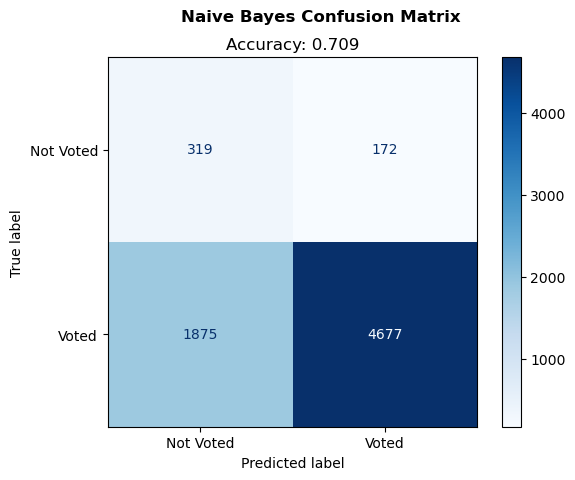

In [66]:
# classification report


# Predict
y_pred = grid_search_b.predict(X_val)

# Evaluate the model

print("\nClassification Report:\n", classification_report(y_val, y_pred))
# Printing Confusion Matrix for first pass
confusion_matrix_ex(y_val, y_pred, ["Not Voted", "Voted"], "Naive Bayes")

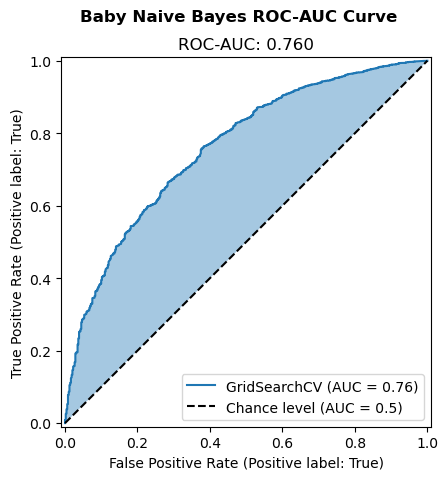

In [67]:
## ROC-AUC

roc_curve_display_ex(grid_search_b, X_val, y_val, y_topic = 'Baby Naive Bayes')

## Expanded Model: Full Feature Set

> Move from the compact baseline to a broader feature space, including behavior, media, civic engagement, and engineered variables.

In [68]:
full_features = [
    # Copy from naive
    'voter_age_group',         # Age Buckets (derived: 2024 - birthyr and converted into buckets)
    'gender4',          # Gender
    'educ',             # Education
    'race',             # Race
    'hispanic',         # Hispanic
    'pid3',             # 3 point party ID
    'inputstate',       # State of Residence
    'region',           # Region
    #'student',          # Student Full or Part-time

    # Multiracial categories
    "multrace_1",       # Multiracial - White
    "multrace_2",       # Multiracial - Black
    "multrace_3",       # Multiracial - Hispanic
    "multrace_4",       # Multiracial - Asian
    "multrace_5",       # Multiracial - Native American
    "multrace_8",       # Multiracial - Middle Eastern
    "multrace_97",      # Multiracial - Other
    "multrace_98",      # Multiracial - Don't know

    # Device & Registration
    'votereg',          # Voter Registration Status

    # Other
    'pid7',             # 7 point Party ID
    'immstat',          # Immigration background

    # Media consumption (past 24 hrs) -- FE
    "CC24_300_1",       # Media use past 24 hrs - Used social media
    "CC24_300_2",       # Media use past 24 hrs - Watched TV news
    "CC24_300_3",       # Media use past 24 hrs - Read a newspaper
    "CC24_300_4",       # Media use past 24 hrs - Listened to radio news
    "CC24_300_5",       # Media use past 24 hrs - None of these

    # Social media use in relation to politics
    "CC24_300d_1",      # Recent social media use - Posted a story, photo, video or link about politics
    "CC24_300d_2",      # Recent social media use - Posted a comment about politics
    "CC24_300d_3",      # Recent social media use - Read a story or watched a video about politics
    "CC24_300d_4",      # Recent social media use - Followed a political event
    "CC24_300d_5",      # Recent social media use - Forwarded a story, photo, video or link about politics to friends
    "CC24_300d_6",      # Recent social media use - None of the above

    # Economic perceptions
    "CC24_301",         # National Economics
    "CC24_302",         # Household income change
    "CC24_303",         # Price change in past year

    # Health status
    "CC24_309e",        # General health

    # Emergency expenses
    "CC24_309d_1",      # Emergency expense - Put it on credit card, pay off in full
    "CC24_309d_2",      # Emergency expense - Put it on credit card, pay off over time
    "CC24_309d_3",      # Emergency expense - With checking/savings or cash
    "CC24_309d_4",      # Emergency expense - Bank loan or line of credit
    "CC24_309d_5",      # Emergency expense - Borrowing from friend or family
    "CC24_309d_6",      # Emergency expense - Payday loan, deposit advance, or overdraft
    "CC24_309d_7",      # Emergency expense - By selling something
    "CC24_309d_8",      # Emergency expense - Wouldn't be able to pay right now

    # Knowledge of current politicians
    "CC24_310a",        # Know Party in Government - U.S. House of Representatives
    "CC24_310b",        # Know Party in Government - U.S. Senate

    # Voting habits
    #"CC24_363",         # Vote Intention - drop bc of data leakage from early voting

    # Miscellaneous
    "urbancity",        # Type of Area Living In
    "ideo5",            # Ideology
    "parent_97",           # Parent of child younger or older than 18
    "employ",           # Employment Status
    "investor",            # Stock ownership
    "newsint",          # Political Interest
    #"faminc_new",       # Family income
    "marstat",          # Marital Status
    "union",            # Labor union member
    "ownhome",          # Home ownership
    "industry",         # Industry of employment
    "jobnum",           # Number of jobs
    "sexuality",        # Sexual Orientation
    "transgender",      # Transgender

    # Religious habit
    "pew_religimp",     # Importance of religion (Pew version)
    "religpew",         # Religion

    # Election habits
    "CC24_421_1",       # Election fair - Elections in the U.S. are fair
    "CC24_421_2",       # Election fair - State/local government conducted fair and accurate election in 2024
    "CC24_423",         # Trust in federal government
    "CC24_424",         # Trust in state government

    # Past year political engagement
    "CC24_430a_1",      # Past year - Attend local political meetings
    "CC24_430a_2",      # Past year - Put up a political sign
    "CC24_430a_3",      # Past year - Work for a candidate or campaign
    "CC24_430a_4",      # Past year - Attend a political protest, march or demonstration
    "CC24_430a_5",      # Past year - Contact a public official
    "CC24_430a_6",      # Past year - Donate money to a candidate, campaign, or political organization
    "CC24_430a_7",      # Past year - Donate blood
    "CC24_430a_8",      # Past year - None of these

    # Money donation
    "CC24_430b_1",      # Donate money - Candidate for President
    "CC24_430b_2",      # Donate money - Candidate for U.S. Senate in my state
    "CC24_430b_3",      # Donate money - Candidate for U.S. Senate in another state
    "CC24_430b_4",      # Donate money - Candidate for U.S. House in my state
    "CC24_430b_5",      # Donate money - Candidate for U.S. House in another state
    "CC24_430b_6",      # Donate money - Candidate for state office
    "CC24_430b_7",      # Donate money - Political party committee
    "CC24_430b_8",      # Donate money - Political action committee at work
    "CC24_430b_9",      # Donate money - Political group
    "CC24_430b_10",     # Donate money - Other
    "CC24_430c",        # Donate money - total amount

    # Campaign contact
    "CC24_431a",        # Contacted by candidate or political campaign

    # Other post-election
    "gunown",           # Personal gun ownership
    #"numchildren",      # Number of children
    "gigwork",          # Gig work
    "edloan",           # Student debtor

    # Voting history
    "presvote20post",   # 2020 President Vote Post Election
    "presvote16post",   # 2016 President Vote Post Election
]

In [306]:
# Check parent values to understand if it's an accurate parent flag

Voting_df['parent_97'].value_counts()

parent_97
2    28328
1    18623
Name: count, dtype: int64

In [307]:
full_df = Voting_df[full_features + ['VoteFlag']].copy()


full_df.shape

(46951, 90)

In [308]:
# Review NAs
(full_df.isna().sum() / len(full_df) * 100).sort_values(ascending = False)

student         95.107665
CC24_430c       76.294435
CC24_430b_4     75.849290
CC24_430b_9     75.849290
CC24_430b_10    75.849290
                  ...    
CC24_430a_6      0.000000
CC24_430a_4      0.000000
CC24_430a_3      0.000000
CC24_430a_1      0.000000
VoteFlag         0.000000
Length: 90, dtype: float64

### Feature Engineering (Expanded Set)

> Consolidate related survey fields into cleaner model-ready indicators and reduce sparsity before final encoding/training.

In [309]:

## Money Donations - categorical end goal

# Review money donation column to understand data structure - looks like CC23_430c, or total amount, should sum to the b's
full_df[['CC24_430c', 'CC24_430b_1', 'CC24_430b_2', 'CC24_430b_3', 'CC24_430b_4']].head(20)

# Create binary
full_df['money_donation'] = full_df['CC24_430c'].notna().astype(int)

# Delete original columns - b is sub questions
full_df.drop(columns=full_df.filter(regex='CC24_430b_|CC24_430c'), inplace=True)




In [310]:
## Student - use student status to identify active students

# DOnt need full vs part time differentiation. ONly student vs non student. NAs should be non students because they didnt answer
full_df['student_active'] = full_df['student'].apply(lambda x: 1 if pd.notna(x) else 0)

# Results
full_df['student_active'].value_counts()


# Drop student

full_df.drop(columns=['student'], inplace = True)

In [311]:
## Job Num
# Drop jobnum because employ captures the categorical variation of this

full_df.drop(columns=['jobnum'], inplace = True)

In [312]:
## edloan - 1 is yes loan, 2 is no loan, NA is non student

full_df['edloan'].value_counts()

# Replace to create 1 if yes loan, 0 if not (students AND non-students)
full_df['student_debt'] = full_df['edloan'].apply(lambda x: 1 if x == 1 else 0)

# Drop edloan

full_df.drop(columns=['edloan'], inplace = True)

In [313]:
## Social Media usage - Political COmmunication - CC24_300d_N
# This is a subset of social media users. NAs mean  non-social media use in past 24 hours
# Goal: 1 = used political social media, 0 = did not use political social media (including non social media users)

# Review values
display(full_df['CC24_300d_6'].value_counts(dropna=False))


# Create new variable
# Is null for for non social media users and x == 1 is for none of the above
full_df['political_media_user'] = full_df['CC24_300d_6'].apply(lambda x: 0 if pd.isnull(x) or x == 1 else 1)


# Drop original variables (all CC23_300d_N)
full_df.drop(columns=full_df.filter(regex='CC24_300d_').columns, inplace=True)





CC24_300d_6
2.0    26528
1.0    11050
NaN     9373
Name: count, dtype: int64

In [314]:
"""  
# â”€â”€ Past year political activities (check all) â”€â”€
    "CC24_430a_1": "Past year - Attend local political meetings",
    "CC24_430a_2": "Past year - Put up a political sign",
    "CC24_430a_3": "Past year - Work for a candidate or campaign",
    "CC24_430a_4": "Past year - Attend a political protest, march or demonstration",
    "CC24_430a_5": "Past year - Contact a public official",
    "CC24_430a_6": "Past year - Donate money to a candidate, campaign, or political organization",
    "CC24_430a_7": "Past year - Donate blood",
    "CC24_430a_8": "Past year - None of these",


"""

## 1 is yes, 2 is no


# Create new variable for any political activity in past year
full_df['past_year_civic_engagement'] = full_df[[
    "CC24_430a_1",
    "CC24_430a_2",
    "CC24_430a_3",
    "CC24_430a_4",
    "CC24_430a_5",
    "CC24_430a_6",
    "CC24_430a_7",
]].apply(lambda x: 1 if x.eq(1).any() else 0, axis=1)

# Drop original variables
full_df.drop(columns=full_df.filter(regex='CC24_430a_').columns, inplace=True)



In [ ]:
## Delete bc conditional

not_in_workforce = [3, 4, 5, 6, 7, 8, 9] # Exclude full time and part time employed

industry_na = Voting_df['industry'].isna()

# Of industry NAs, what employ values appear?
print("employ distribution where industry is NaN:")
print(Voting_df.loc[industry_na, 'employ'].value_counts(dropna=False))

print("\n--- Key stats ---")
na_and_not_workforce = industry_na & Voting_df['employ'].isin(not_in_workforce)
print(f"industry NAs that ARE not-in-workforce employ: {na_and_not_workforce.sum()} ({na_and_not_workforce.sum()/industry_na.sum():.1%} of NAs)")

na_and_in_workforce = industry_na & ~Voting_df['employ'].isin(not_in_workforce)
print(f"industry NAs that ARE in-workforce employ:     {na_and_in_workforce.sum()} ({na_and_in_workforce.sum()/industry_na.sum():.1%} of NAs)")



employ distribution where industry is NaN:
employ
6.0    2500
7.0    1381
4.0     785
8.0     243
9.0     224
5.0      79
1.0      65
2.0      30
NaN      29
3.0      14
Name: count, dtype: int64

--- Key stats ---
industry NAs that ARE not-in-workforce employ: 5226 (97.7% of NAs)
industry NAs that ARE in-workforce employ:     124 (2.3% of NAs)


In [316]:
# Make NAs in industry column into "No Industry"
full_df['industry'] = full_df['industry'].fillna('0')

full_df['industry'] = full_df['industry'].astype(int)

In [317]:
# Do mode inputat



# Remaining NAs - get column names that still have NA
na_cols = full_df.columns[full_df.isna().any()].tolist()

# Inpute
imputer = SimpleImputer(strategy='most_frequent')
full_df[na_cols] = imputer.fit_transform(full_df[na_cols])

## Expanded Model Training and Evaluation

> Encode, split, tune, and evaluate the full-feature Naive Bayes pipeline using the same evaluation framework as the baseline model.

In [318]:
# Which columns are float and string
float_cols = full_df.select_dtypes(include=['float64']).columns.tolist()
object_cols = full_df.select_dtypes(include=['object']).columns.tolist()
print("Float columns:", float_cols)
print("Object columns:", object_cols)


# Check if any of the float columns have decimal values or if they are actually categorical variables that should be converted to int
for col in float_cols:
    unique_values = full_df[col].dropna().unique()
    print(f"Column: {col}, Unique Values: {unique_values}")

# Convert all float columns to int
# This is because they are all categorical variables that were read in as float due to the presence of NaNs, but we have imputed those NaNs and they should be integers
for col in float_cols:
    full_df[col] = full_df[col].astype(int)    

Float columns: ['multrace_97', 'immstat', 'CC24_301', 'CC24_302', 'CC24_303', 'CC24_309e', 'CC24_310a', 'CC24_310b', 'urbancity', 'ideo5', 'employ', 'investor', 'newsint', 'marstat', 'union', 'ownhome', 'sexuality', 'transgender', 'pew_religimp', 'religpew', 'CC24_421_1', 'CC24_421_2', 'CC24_423', 'CC24_424', 'CC24_431a', 'gunown', 'gigwork', 'presvote20post', 'presvote16post']
Object columns: []
Column: multrace_97, Unique Values: [2.]
Column: immstat, Unique Values: [5. 4. 3. 1.]
Column: CC24_301, Unique Values: [3. 1. 5. 2. 6. 4.]
Column: CC24_302, Unique Values: [3. 2. 4. 5. 1.]
Column: CC24_303, Unique Values: [3. 2. 4. 1. 5.]
Column: CC24_309e, Unique Values: [1. 2. 4. 3. 5.]
Column: CC24_310a, Unique Values: [4. 1. 2. 3.]
Column: CC24_310b, Unique Values: [4. 2. 1. 3.]
Column: urbancity, Unique Values: [1. 2. 3. 4. 5.]
Column: ideo5, Unique Values: [3. 4. 1. 2. 6. 5.]
Column: employ, Unique Values: [6. 1. 5. 4. 3. 2. 7. 9. 8.]
Column: investor, Unique Values: [ 2. 99.  1.]
Colum

In [319]:
# Break into features and target
X = full_df.drop(columns=['VoteFlag'])
Y = full_df['VoteFlag']

# Pd_cut made age buckets, but need to encode
enc = OrdinalEncoder()
enc.set_output(transform="pandas")

X_encoded = enc.fit_transform(X)

In [320]:
# Understand value range
X_encoded.describe()

,voter_age_group,gender4,educ,race,hispanic,pid3,inputstate,region,multrace_1,multrace_2,...,CC24_431a,gunown,gigwork,presvote20post,presvote16post,money_donation,student_active,student_debt,political_media_user,past_year_civic_engagement
count,46951.000000,46951.000000,46951.000000,46951.000000,46951.000000,46951.000000,46951.000000,46951.000000,46951.000000,46951.000000,...,46951.000000,46951.000000,46951.000000,46951.000000,46951.00000,46951.000000,46951.000000,46951.000000,46951.000000,46951.000000
mean,1.993525,0.535857,2.782369,0.587911,0.910886,1.020724,24.872782,1.608294,0.686546,0.955060,...,0.376946,1.399566,0.863134,1.028839,1.73779,0.237056,0.048923,0.096547,0.565015,0.485016
std,0.921082,0.516962,1.462446,1.338326,0.284912,0.988376,14.843284,1.010605,0.463902,0.207176,...,0.484626,0.934605,0.343710,1.563896,2.26663,0.425281,0.215710,0.295344,0.495760,0.499781
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,10.000000,1.000000,0.000000,1.000000,...,0.000000,0.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.000000,1.000000,3.000000,0.000000,1.000000,1.000000,25.000000,2.000000,1.000000,1.000000,...,0.000000,2.000000,1.000000,1.000000,1.00000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,3.000000,1.000000,4.000000,0.000000,1.000000,2.000000,38.000000,2.000000,1.000000,1.000000,...,1.000000,2.000000,1.000000,1.000000,2.00000,0.000000,0.000000,0.000000,1.000000,1.000000
max,3.000000,3.000000,5.000000,7.000000,1.000000,4.000000,50.000000,3.000000,1.000000,1.000000,...,1.000000,3.000000,1.000000,5.000000,6.00000,1.000000,1.000000,1.000000,1.000000,1.000000


In [321]:
# Train-validation-test split (70 / 15 / 15)
X_pass, X_orig_test, y_pass, y_orig_test = train_test_split(X_encoded, Y, test_size=0.3, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_orig_test, y_orig_test, test_size=0.5, random_state=42)

In [322]:
# Undersample majority class to balance training data
rus = RandomUnderSampler(random_state=42)
X_train, y_train = rus.fit_resample(X_pass, y_pass)

In [323]:
# Review class imbalance
y_train.value_counts() / len(Y) * 100

VoteFlag
False    4.647398
True     4.647398
Name: count, dtype: float64

In [324]:
# Define the model
# min_categories ensures CategoricalNB allocates enough category slots per feature
# even when a CV fold's training split is missing rare category values
min_cats = (X_encoded.max() + 1).astype(int).tolist()

# Set class prior to an even 50/50 baseline
bayes_model = CategoricalNB(class_prior=[0.5, 0.5], min_categories=min_cats)

### Expanded Hyperparameter Tuning

> Repeat grid search on `alpha` for the expanded feature matrix to maximize validation ROC-AUC.

In [325]:
# Pass 1

param_grid_b = [
    {
        'alpha': [0.01, 0.1, 0.5, 1.0, 2.0, 10.0]
    }
]

grid_search_b = GridSearchCV(
    estimator=bayes_model,
    param_grid=param_grid_b,
    cv=3,
    scoring='roc_auc',
    refit=True,
    verbose=3
)

grid_search_b.fit(X_train, y_train)

print(f"Best Params: {grid_search_b.best_params_}")
gs_results_b = grid_search_b.cv_results_

Fitting 3 folds for each of 6 candidates, totalling 18 fits
[CV 1/3] END ........................alpha=0.01;, score=0.873 total time=   0.0s
[CV 2/3] END ........................alpha=0.01;, score=0.868 total time=   0.0s
[CV 3/3] END ........................alpha=0.01;, score=0.875 total time=   0.0s
[CV 1/3] END .........................alpha=0.1;, score=0.874 total time=   0.0s
[CV 2/3] END .........................alpha=0.1;, score=0.868 total time=   0.0s
[CV 3/3] END .........................alpha=0.1;, score=0.874 total time=   0.0s
[CV 1/3] END .........................alpha=0.5;, score=0.874 total time=   0.0s
[CV 2/3] END .........................alpha=0.5;, score=0.868 total time=   0.0s
[CV 3/3] END .........................alpha=0.5;, score=0.874 total time=   0.0s
[CV 1/3] END .........................alpha=1.0;, score=0.874 total time=   0.0s
[CV 2/3] END .........................alpha=1.0;, score=0.868 total time=   0.0s
[CV 3/3] END .........................alpha=1.0;,

In [326]:
# Pass 2
param_grid_b = [
    {
        'alpha': [0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5]
    }
]

grid_search_b = GridSearchCV(
    estimator=bayes_model,
    param_grid=param_grid_b,
    cv=3,
    scoring='roc_auc',
    refit=True,
    verbose=3
)

grid_search_b.fit(X_train, y_train)

print(f"Best Params: {grid_search_b.best_params_}")
gs_results_b = grid_search_b.cv_results_

Fitting 3 folds for each of 7 candidates, totalling 21 fits
[CV 1/3] END ........................alpha=0.05;, score=0.874 total time=   0.0s
[CV 2/3] END ........................alpha=0.05;, score=0.868 total time=   0.0s
[CV 3/3] END ........................alpha=0.05;, score=0.874 total time=   0.0s
[CV 1/3] END .........................alpha=0.1;, score=0.874 total time=   0.0s
[CV 2/3] END .........................alpha=0.1;, score=0.868 total time=   0.0s
[CV 3/3] END .........................alpha=0.1;, score=0.874 total time=   0.0s
[CV 1/3] END ........................alpha=0.15;, score=0.874 total time=   0.0s
[CV 2/3] END ........................alpha=0.15;, score=0.868 total time=   0.0s
[CV 3/3] END ........................alpha=0.15;, score=0.874 total time=   0.0s
[CV 1/3] END .........................alpha=0.2;, score=0.874 total time=   0.0s
[CV 2/3] END .........................alpha=0.2;, score=0.868 total time=   0.0s
[CV 3/3] END .........................alpha=0.2;,


Classification Report:
               precision    recall  f1-score   support

       False       0.21      0.79      0.34       491
        True       0.98      0.78      0.87      6552

    accuracy                           0.78      7043
   macro avg       0.60      0.79      0.60      7043
weighted avg       0.93      0.78      0.83      7043



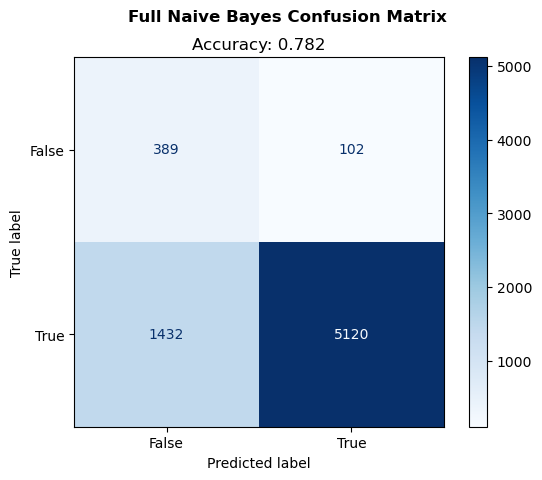

In [327]:

# classification report


# Predict
y_pred = grid_search_b.predict(X_val)

# Evaluate the model

print("\nClassification Report:\n", classification_report(y_val, y_pred))
# Printing Confusion Matrix for first pass
confusion_matrix_ex(y_val, y_pred, ["False", "True"], "Full Naive Bayes")

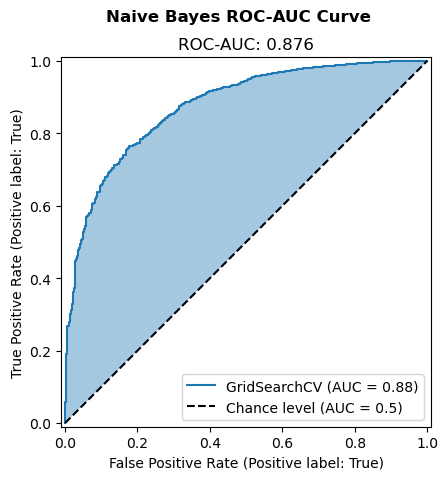

In [328]:
## ROC-AUC

roc_curve_display_ex(grid_search_b, X_val, y_val, y_topic = 'Naive Bayes')

## Model Interpretation

> Interpret the tuned model with two views:
- global ranking via log-probability deltas (feature importance)
- local/global effect patterns via SHAP summaries

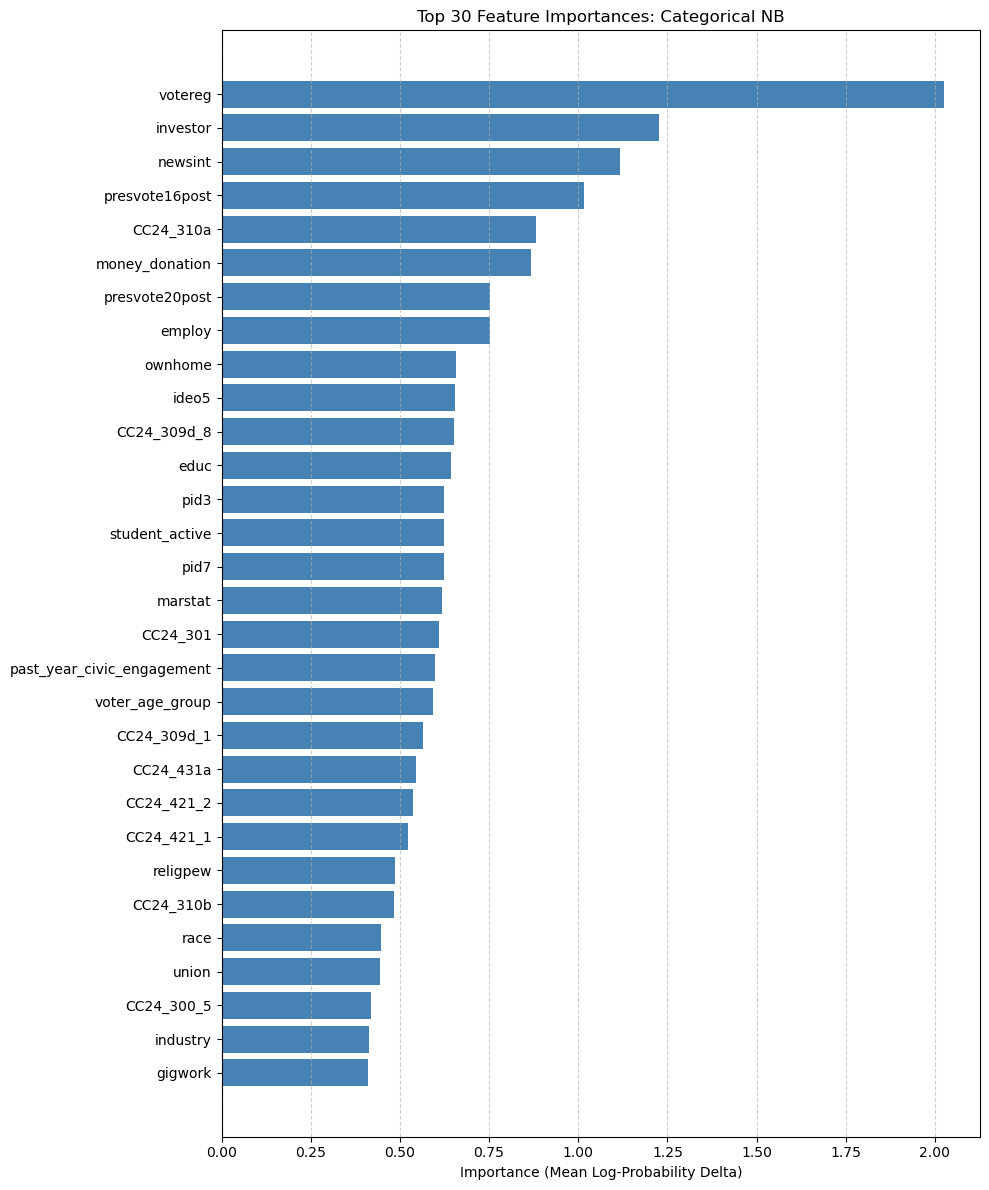

In [329]:
# 1. Access the underlying model from the GridSearch object
best_model = grid_search_b.best_estimator_

importances = []
for i in range(len(X.columns)):
    # Access the log probabilities from the best estimator
    log_probs = best_model.feature_log_prob_[i]
    
    # Calculate the average magnitude of the difference between class 0 (No Vote) and 1 (Vote)
    # This measures how much this feature discriminates between the two outcomes
    diff = np.mean(np.abs(log_probs[0] - log_probs[1]))
    importances.append(diff)

# 2. Prepare Data for Plotting
feat_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

# 3. Graphing
# Since you have 90 features, showing just the top 30 makes the chart readable
top_n = 30
plot_data = feat_importance.tail(top_n)

plt.figure(figsize=(10, 12)) 
plt.barh(plot_data['Feature'], plot_data['Importance'], color='steelblue')
plt.xlabel('Importance (Mean Log-Probability Delta)')
plt.title(f'Top {top_n} Feature Importances: Categorical NB')
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

  0%|          | 0/50 [00:00<?, ?it/s]

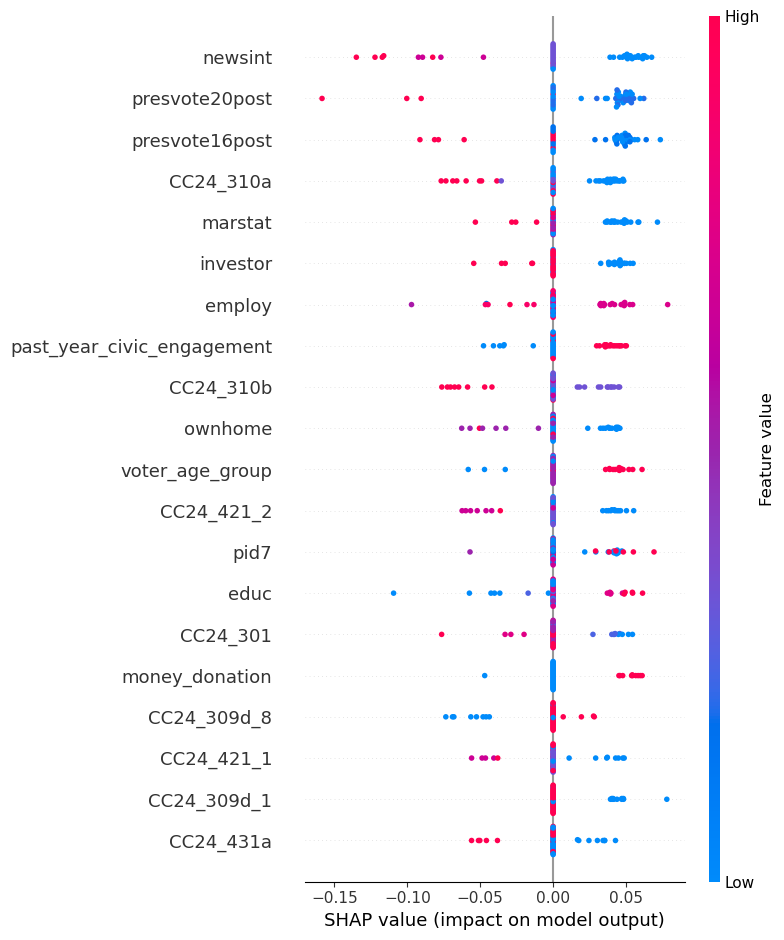

In [330]:
# Use the fitted full Naive Bayes model from the grid search
best_model = grid_search_b.best_estimator_

# Sample rows with shap.sample for a tractable KernelExplainer run
background_data = shap.sample(X_train, 100, random_state=42)
explain_data = shap.sample(X_val, 50, random_state=42)

explainer = shap.KernelExplainer(best_model.predict_proba, background_data)
shap_values = explainer.shap_values(explain_data)

# SHAP returns either a list per class or a 3D array depending on version
if isinstance(shap_values, list):
    class_1_values = shap_values[1]
elif getattr(shap_values, 'ndim', None) == 3:
    class_1_values = shap_values[:, :, 1]
else:
    class_1_values = shap_values

shap.summary_plot(class_1_values, explain_data, feature_names=explain_data.columns)

In [331]:

feature_name = "newsint"
feature_idx = list(explain_data.columns).index(feature_name)

# SHAP contributions for class 1 (you already created class_1_values)
newsint_shap = class_1_values[:, feature_idx]

# Encoded category values used in explain_data
newsint_encoded = explain_data[feature_name].values

# Aggregate impact by encoded category
newsint_impact = (
    pd.DataFrame({
        "newsint_encoded": newsint_encoded,
        "shap": newsint_shap
    })
    .groupby("newsint_encoded", as_index=False)
    .agg(
        count=("shap", "size"),
        mean_shap=("shap", "mean"),
        mean_abs_shap=("shap", lambda s: np.mean(np.abs(s)))
    )
    .sort_values("mean_abs_shap", ascending=False)
)

newsint_impact.head(10)




,newsint_encoded,count,mean_shap,mean_abs_shap
3,3.0,5,-0.114632,0.114632
2,2.0,5,-0.061350,0.061350
0,0.0,25,0.049856,0.049856
1,1.0,15,0.000000,0.000000


In [332]:
feature_idx = list(explain_data.columns).index("newsint")
print("All known categories:", enc.categories_[feature_idx])
print("Categories in sample: ", explain_data["newsint"].unique())

All known categories: [1 2 3 4 7]
Categories in sample:  [0. 1. 2. 3.]


## Final Test
Running model on test set


Classification Report:
               precision    recall  f1-score   support

       False       0.22      0.75      0.34       514
        True       0.98      0.79      0.87      6529

    accuracy                           0.78      7043
   macro avg       0.60      0.77      0.60      7043
weighted avg       0.92      0.78      0.83      7043



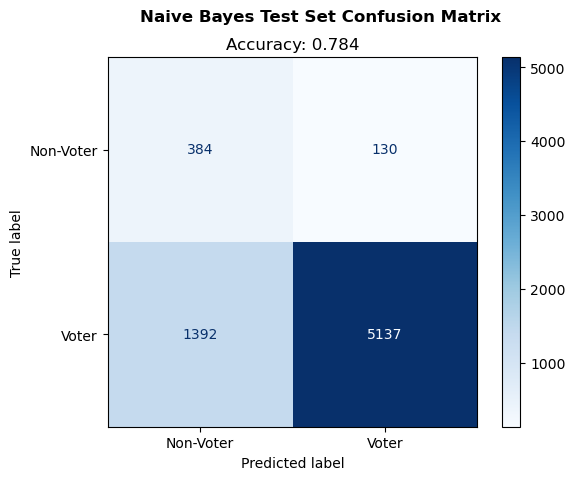

In [333]:
# Classification Report on Test


# Predict
y_pred = grid_search_b.predict(X_test)

# Evaluate the model

print("\nClassification Report:\n", classification_report(y_test, y_pred))
# Printing Confusion Matrix for first pass
confusion_matrix_ex(y_test, y_pred, ["Non-Voter", "Voter"], "Naive Bayes Test Set")

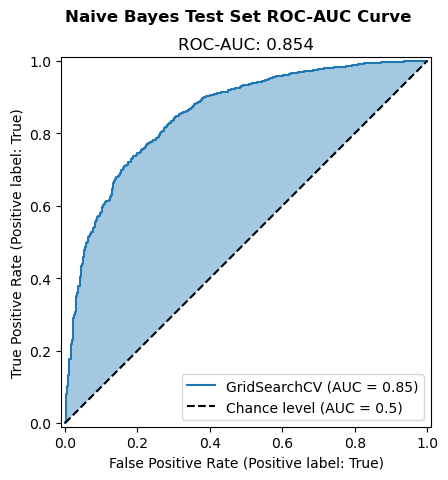

In [334]:
# ROC-AUC Curve
roc_curve_display_ex(grid_search_b, X_test, y_test, y_topic='Naive Bayes Test Set')

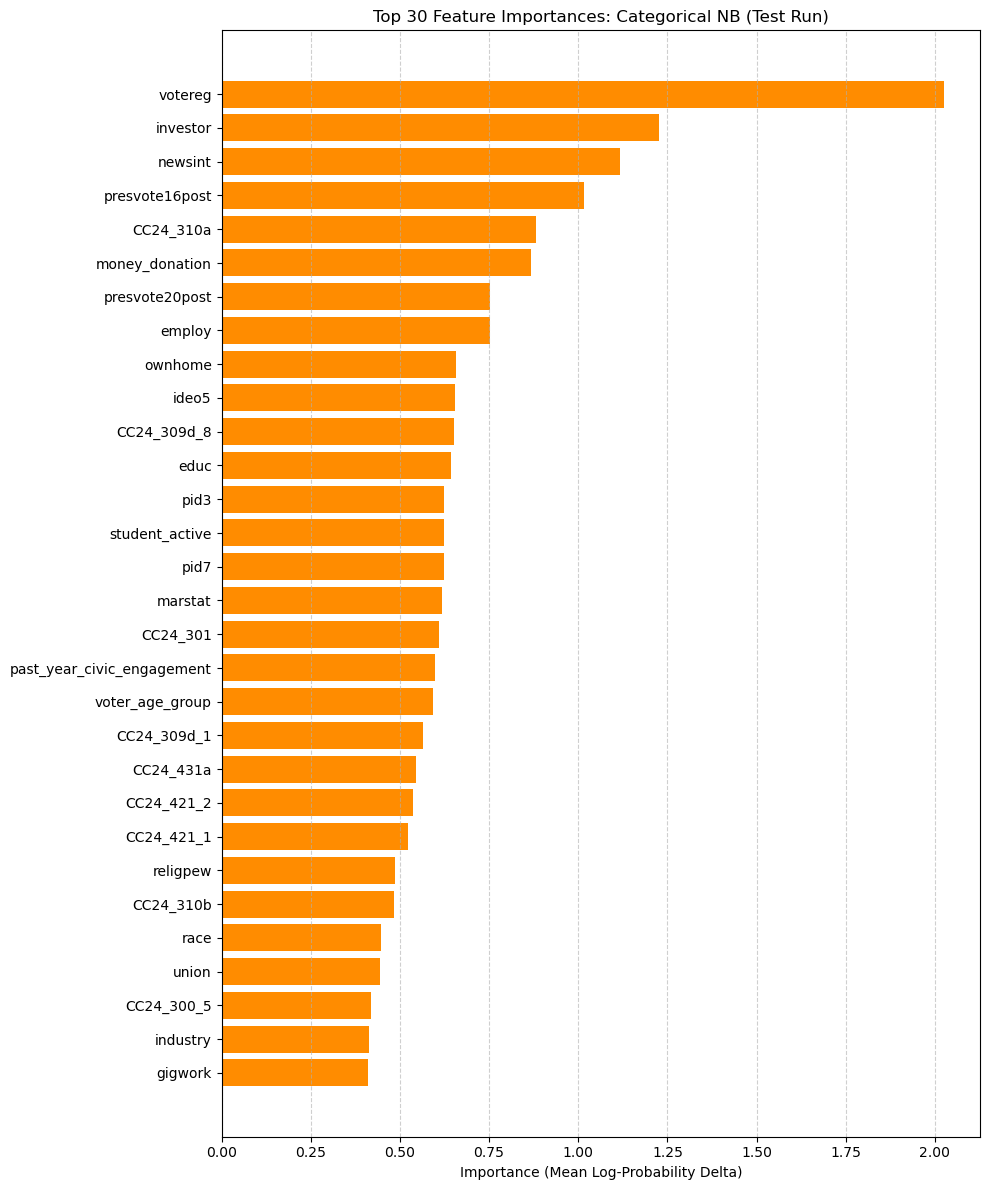

In [335]:
# Feature Importance using the tuned model evaluated on the test split
best_model = grid_search_b.best_estimator_

test_importances = []
for i in range(len(X.columns)):
    log_probs = best_model.feature_log_prob_[i]
    diff = np.mean(np.abs(log_probs[0] - log_probs[1]))
    test_importances.append(diff)

test_feat_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': test_importances
}).sort_values(by='Importance', ascending=True)

top_n = 30
test_plot_data = test_feat_importance.tail(top_n)

plt.figure(figsize=(10, 12))
plt.barh(test_plot_data['Feature'], test_plot_data['Importance'], color='darkorange')
plt.xlabel('Importance (Mean Log-Probability Delta)')
plt.title(f'Top {top_n} Feature Importances: Categorical NB (Test Run)')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

  0%|          | 0/50 [00:00<?, ?it/s]

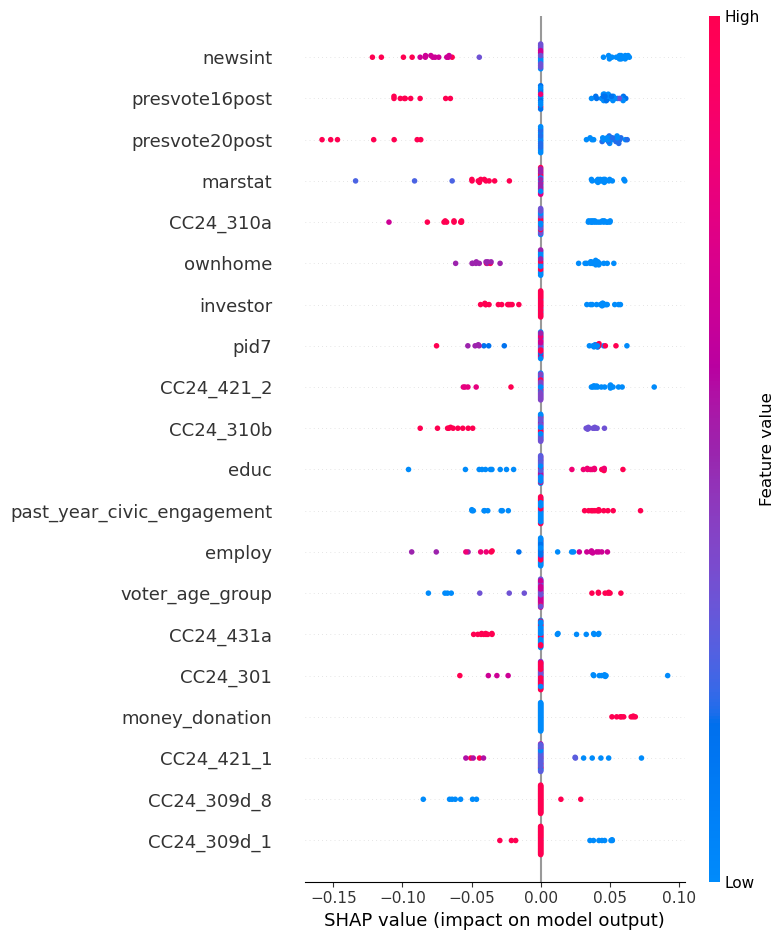

In [336]:
# SHAP summary for the test split
best_model = grid_search_b.best_estimator_

test_background_data = shap.sample(X_train, 100, random_state=42)
test_explain_data = shap.sample(X_test, 50, random_state=42)

test_explainer = shap.KernelExplainer(best_model.predict_proba, test_background_data)
test_shap_values = test_explainer.shap_values(test_explain_data)

if isinstance(test_shap_values, list):
    test_class_1_values = test_shap_values[1]
elif getattr(test_shap_values, 'ndim', None) == 3:
    test_class_1_values = test_shap_values[:, :, 1]
else:
    test_class_1_values = test_shap_values

shap.summary_plot(test_class_1_values, test_explain_data, feature_names=test_explain_data.columns)